# Optimization

## Initialize

In [ ]:
# import required libraries
import numpy as np
from numpy.polynomial.polynomial import Polynomial
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.optimize import minimize
import tensorflow as tf #type: ignore
import torch #type: ignore
#
from IPython.display import display, Math
# Import typyng library for type hinting
from typing import Callable, Union, List, Any, Tuple

## Example os convex vs non-convex optimization

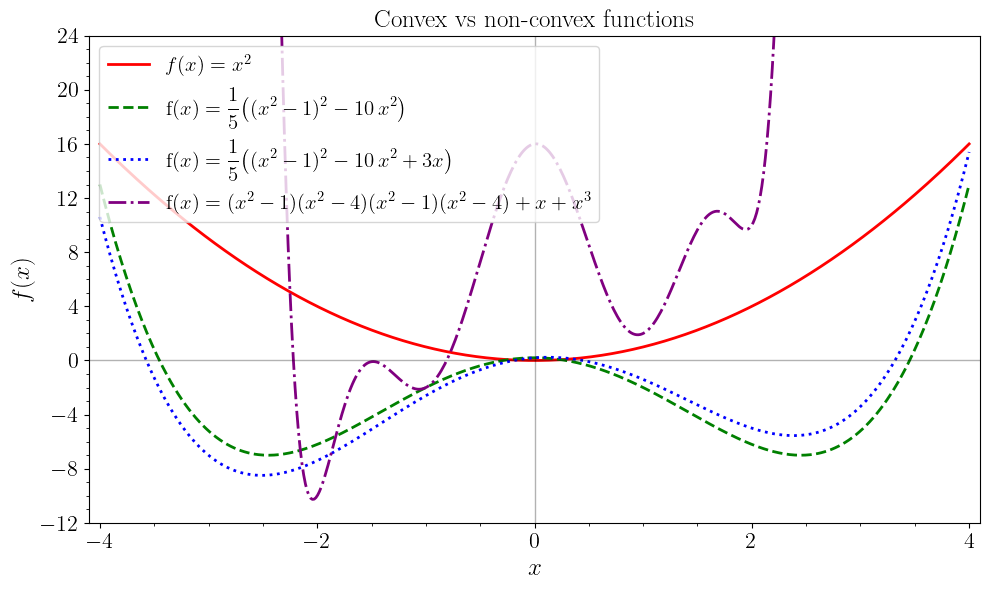

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Enable LaTeX rendering for text
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['text.latex.preamble'] = r"""\usepackage{amsmath}
\usepackage{amsfonts}
\usepackage{amssymb}
\usepackage{bm}"""

# Define the functions
def f(x):
    return x**2

def g(x):
    return (1/5)*((x**2 - 1)**2 - 10*(x**2))

def h(x):
    return (1/5)*((x**2 - 1)**2 - 10*(x**2) + 3*x)

def h2(x):
    return (x**2 - 1)*(x**2 - 4)*(x**2 - 1)*(x**2 - 4)+x+x**3

# Create a range of x-values
x = np.linspace(-4, 4, 500)

# Evaluate the functions
fvals = f(x)
gvals = g(x)
hvals = h(x)
h2vals = h2(x)

# --- Generate custom tick marks ---
x_major_ticks = np.arange(-4, 4.1, 2)
x_minor_ticks = np.arange(-4, 4.1, 0.5)
y_major_ticks = np.arange(-12, 25, 4)
y_minor_ticks = np.arange(-12, 25, 1)

# Create the figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the three functions with custom line styles (similar to Mathematica's Dashing)
# - Dashing[0.038] -> a short-dashed style
# - Dashing[0.015] -> a more sparse dashed style
# - Dashing[0.01]  -> an even more sparse dashed style
# The line-style tuples (offset, (on, off)) can be adjusted for a closer match.

ax.plot(x, fvals, color='red', linewidth=2,
        linestyle="-",  # short-dashed
        label=r'$f(x)=x^2$')

ax.plot(x, gvals, color='green', linewidth=2,
        linestyle="--",  # more sparse dashed
        label=(
            r'$\displaystyle \text{f}(x)=\frac{1}{5}\bigl((x^2-1)^2'
            r'-10\,x^2\bigr)$'
        ))

ax.plot(x, hvals, color='blue', linewidth=2,
        linestyle=":",  # even more sparse dashed
        label=(
            r'$\displaystyle \text{f}(x)=\frac{1}{5}\bigl((x^2-1)^2'
            r'-10\,x^2+3x\bigr)$'
        ))

ax.plot(x, h2vals, color='purple', linewidth=2,
        linestyle="-.",  # custom dashed style
        label=(
            r'$\displaystyle \text{f}(x)=(x^2-1)(x^2-4)(x^2-1)(x^2-4)+x+x^3$'
        ))

# Set x and y limits to match your PlotRange
ax.set_xlim(-4.1, 4.1)
ax.set_ylim(-9.2, 22.2)

# Draw axes
ax.axhline(y=0, color='k', linestyle='-', linewidth=1, alpha=0.3)
ax.axvline(x=0, color='k', linestyle='-', linewidth=1, alpha=0.3)
# Set title
plt.title(f'Convex vs non-convex functions', fontsize = 18)
# Set custom ticks
ax.set_xticks(x_major_ticks)
ax.set_xticks(x_minor_ticks, minor=True)
ax.set_yticks(y_major_ticks)
ax.set_yticks(y_minor_ticks, minor=True)
ax.tick_params(axis='both', which='major', labelsize=16)
# Axis labels
ax.set_xlabel(r'$x$', fontsize=18)
ax.set_ylabel(r'$f(x)$', fontsize=18)

# Legend
ax.legend(loc='upper left', fontsize=15)

# Optional grid
#ax.grid(True, alpha=0.3)

plt.tight_layout()

# Save and show
plt.savefig(f'/Users/rtorre/Dropbox/Apps/Overleaf/ML Methods for Physics/Figures/Chapter_3/convex_non_convex_example.pdf')
plt.show()

## Probabilistic model (linear data - linear model)

In [501]:
def poly(x: np.ndarray, 
         omega: np.ndarray, 
         noise_std: float = 0.
        ) -> np.ndarray:
    """
    Evaluates a polynomial with coefficients omega at x, adding independent Gaussian noise 
    to each coefficient for each data point.
    
    Parameters
    ----------
    x : np.ndarray
        Input values. Can be a scalar or a 1D numpy array.
    omega : np.ndarray
        Coefficients of the polynomial.
    noise_std : float, optional
        Standard deviation of the Gaussian noise added to each coefficient, by default 1.
        
    Returns
    -------
    np.ndarray or float
        The output of the polynomial function evaluated at each x, with independent noise for each data point.
    """
    np.random.seed(0)
    # Ensure x is an array.
    x = np.atleast_1d(x)
    # Number of coefficients.
    k = len(omega)
    # For each coefficient, compute the corresponding powers of x: this creates a (k, len(x)) array.
    powers = np.array([x**i for i in range(k)])
    # Generate independent noise for each coefficient and each data point.
    noise = np.random.normal(0, noise_std, size=powers.shape)
    # Add noise to the coefficients and multiply elementwise by the power of x.
    effective_terms = (omega.reshape(-1, 1) + noise) * powers
    # Sum over the coefficients (axis 0) to get the final result.
    result = effective_terms.sum(axis=0)
    # If x was originally a scalar, return a scalar.
    if result.size == 1:
        return result.item()
    return result

def p(x: float, 
      omega: np.ndarray,
      noise_std: float = 0.
      ) -> float:
    """Computes the logistic function output given x and coefficients omega.
    
    Parameters
    ----------
    x : float
        Input value.
    omega : np.ndarray
        Coefficients for the polynomial inside the logistic function.
    
    Returns
    -------
    float
        Logistic function value.
    """
    poly_val = poly(x, omega, noise_std)
    return 1.0 / (1.0 + np.exp(-poly_val))

def p_approx(x: float, 
             omega: np.ndarray,
             noise_std: float = 0.
             ) -> float:
    """Computes the logistic function output given x and coefficients omega.
    
    Parameters
    ----------
    x : float
        Input value.
    omega : np.ndarray
        Coefficients for the polynomial inside the logistic function.
    
    Returns
    -------
    float
        Logistic function value.
    """
    poly_val = poly(x, omega, noise_std)
    return 1./2 + poly_val/4.

def design_matrix(x: np.ndarray, degree: int) -> np.ndarray:
    """Computes the design matrix for a polynomial of a given degree.
    
    Parameters
    ----------
    x : np.ndarray
        Input values.
    degree : int
        Degree of the polynomial.
    
    Returns
    -------
    np.ndarray
        Design matrix.
    """
    X = np.zeros((len(x), degree + 1))
    for i in range(degree + 1):
        X[:, i] = x**i
    return X

In [502]:
# Define the true parameters
omega_true = np.array([2, -3])

# Define the objective: squared difference between y(x,omega_true) and 0.5.
def objective(x, omega):
    # x comes as an array of one element; extract the scalar.
    x_scalar = x[0]
    return (p(x_scalar, omega) - 0.5)**2

# Define the approximate objective: squared difference between y_approx(x,omega_true) and 0.5.
def objective_approx(x, omega):
    # x comes as an array of one element; extract the scalar.
    x_scalar = x[0]
    return (p_approx(x_scalar, omega) - 0.5)**2

# Initial guess for x (e.g., 0)
initial_x = np.array([0.0])

# Optimize using minimize; here we pass omega_true as an extra argument.
result = minimize(objective, initial_x, args=(omega_true,), method='BFGS')

# Optimize using minimize; here we pass omega_true as an extra argument.
result_approx = minimize(objective_approx, initial_x, args=(omega_true,), method='BFGS')

print("Decision boundary x =", result.x[0])
print("Objective value =", result.fun)
decision_boundary = result.x[0]

print("Decision boundary (from approx solution) x =", result_approx.x[0])
print("Objective value (from approx solution) =", result_approx.fun)

Decision boundary x = 0.6666669622623926
Objective value = 4.914946870639898e-14
Decision boundary (from approx solution) x = 0.6666666593080686
Objective value (from approx solution) = 3.0458793996399694e-17


In [503]:
# Generate data coordinates
x_train = np.sort(np.concatenate(((2/3) - 0.02 * np.arange(1, 101),(2/3) + 0.02 * np.arange(1, 101))))
x_val = np.sort(np.concatenate(((2/3) - 0.04 * np.arange(1, 51),(2/3) + 0.04 * np.arange(1, 51)))) + 0.03
x_test = np.sort(np.concatenate(((2/3) - 0.04 * np.arange(1, 51),(2/3) + 0.04 * np.arange(1, 51)))) - 0.03

X_train = design_matrix(x_train, 1)
X_val = design_matrix(x_val, 1)
X_test = design_matrix(x_test, 1)

p_train = p(x_train, omega_true, noise_std=1)
p_val = p(x_val, omega_true, noise_std=1)
p_test = p(x_test, omega_true, noise_std=1)

Y_train = np.array([1 if p_i >= 0.5 else 0 for p_i in p_train])
Y_val = np.array([1 if p_i >= 0.5 else 0 for p_i in p_val])
Y_test = np.array([1 if p_i >= 0.5 else 0 for p_i in p_test])

print("Train data for class 1:", np.count_nonzero(Y_train), "out of", len(Y_train))
print("Validation data for class 1:", np.count_nonzero(Y_val), "out of", len(Y_val))
print("Test data for class 1:", np.count_nonzero(Y_test), "out of", len(Y_test))

Train data for class 1: 106 out of 200
Validation data for class 1: 46 out of 100
Test data for class 1: 47 out of 100


In [504]:
omega_approx = np.linalg.pinv(X_train.T @ X_train) @ (4 * X_train.T @ Y_train - 2 * X_train.T @ np.ones_like(Y_train))
print("Approximate omega:", omega_approx)

result_approx = minimize(objective_approx, initial_x, args=(omega_true,), method='BFGS')

print("Decision boundary (from approx solution) x =", result_approx.x[0])

Approximate omega: [ 1.06872174 -1.42308261]
Decision boundary (from approx solution) x = 0.6666666593080686


In [724]:
def Y_pred(p: np.ndarray, 
           threshold: float = 0.5
          ) -> np.ndarray:
    """Converts probabilities to predictions using a threshold.
    
    Parameters
    ----------
    p : np.ndarray
        Probabilities.
    threshold : float
        Threshold for the conversion.
    
    Returns
    -------
    np.ndarray
        Predictions.
    """
    return (p >= threshold).astype(int)#np.array([1 if p_i > threshold else 0 for p_i in p])

def loss_fn(X: np.ndarray, 
            p: np.ndarray, 
            omega: np.ndarray,
            threshold: float = 0.5
           ) -> float:
    """Computes the logistic loss for a given dataset and parameters.
    
    Parameters
    ----------
    X : np.ndarray
        Design matrix.
    Y : np.ndarray
        Target values.
    omega : np.ndarray
        Parameters.
    
    Returns
    -------
    float
        Logistic loss.
    """
    Y = Y_pred(p, threshold)
    res = X.T @ Y @ omega - np.sum(np.log(1 + np.exp(X @ omega)))
    return -1/len(Y) * res

# Define the gradient of the loss at the point omega.
def grad_loss_fn(X: np.ndarray, 
                 p: np.ndarray, 
                 omega: np.ndarray,
                 threshold: float = 0.5
                ) -> np.ndarray:
    """Computes the gradient of the logistic loss for a given dataset and parameters.
    
    Parameters
    ----------
    X : np.ndarray
        Design matrix.
    Y : np.ndarray
        Target values.
    omega : np.ndarray
        Parameters.
    
    Returns
    -------
    np.ndarray
        Gradient of the logistic loss.
    """
    Y = Y_pred(p, threshold)
    return -1/len(Y) * (X.T @ (Y - 1/(1 + np.exp(-X @ omega))))

# Define the Hessian of the loss at the point omega.
def hess_loss_fn(X: np.ndarray, 
                 p: np.ndarray, 
                 omega: np.ndarray,
                 threshold: float = 0.5
                ) -> np.ndarray:
    """Computes the Hessian of the logistic loss for a given dataset and parameters.
    
    Parameters
    ----------
    X : np.ndarray
        Design matrix.
    Y : np.ndarray
        Target values.
    omega : np.ndarray
        Parameters.
    
    Returns
    -------
    np.ndarray
        Hessian of the logistic loss.
    """
    Y = Y_pred(p, threshold)
    S = np.diag(np.exp(-X @ omega) / (1 + np.exp(-X @ omega))**2)
    return 1/len(Y) * (X.T @ S @ X)

### Newton-Raphson

In [506]:
# Define the Newton method.
def newton_method(X: np.ndarray, 
                  p: np.ndarray, 
                  omega_init: np.ndarray, 
                  threshold: float = 0.5, 
                  tol: float = 1e-6, 
                  max_iter: int = 10
                 ) -> Tuple[np.ndarray, List[float]]:
    """Newton method for logistic regression.
    
    Parameters
    ----------
    X : np.ndarray
        Design matrix.
    Y : np.ndarray
        Target values.
    omega_init : np.ndarray
        Initial parameters.
    threshold : float, optional
        Threshold for the conversion, by default 0.5.
    tol : float, optional
        Tolerance for stopping criterion, by default 1e-6.
    max_iter : int, optional
        Maximum number of iterations, by default 100.
    
    Returns
    -------
    np.ndarray
        Optimal parameters.
    List[float]
        Loss values at each iteration.
    """
    omega = omega_init
    omegas = [omega]
    losses = [loss_fn(X, p, omega, threshold)]
    for i in range(max_iter):
        grad = grad_loss_fn(X, p, omega, threshold)
        hess = hess_loss_fn(X, p, omega, threshold)
        omega = omega - np.linalg.inv(hess) @ grad
        omegas.append(omega)
        loss = loss_fn(X, p, omega, threshold)
        losses.append(loss)
        if np.linalg.norm(grad) < tol:
            break
    return np.array(omegas), np.array(losses)

In [507]:
# Minimize the loss using the Newton method.
omegas_newton0, losses_newton0 = newton_method(X_train, p_train, np.array([0.0,0.0]))
omegas_newtonp1, losses_newtonp1 = newton_method(X_train, p_train, np.array([1.0,0.0]))
omegas_newtonm1, losses_newtonm1 = newton_method(X_train, p_train, np.array([0.0,-1.0]))

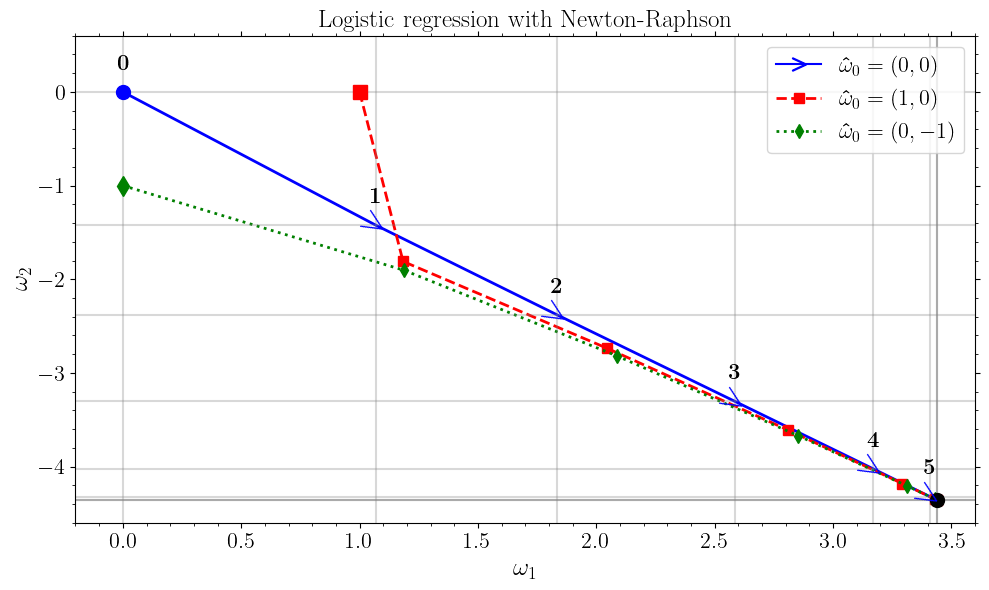

In [518]:
# --- Define data --- 
n_iter = len(omegas_newton0)
omegaEvolution0 = omegas_newton0
omegaEvolutionp1 = omegas_newtonp1
omegaEvolutionm1 = omegas_newtonm1

x_min, x_max = -0.2, 3.6
y_min, y_max = -4.6, 0.6

# --- Create custom tick arrays (you can adjust these as desired) ---
x_major_ticks = np.linspace(-0.5, 4, 10)
y_major_ticks = np.linspace(-5, 1, 7)

# For minor ticks, you can interpolate more finely:
x_minor_ticks = np.linspace(-0.5, 4, 46)
y_minor_ticks = np.linspace(-5, 1, 31)

# Enable LaTeX rendering for text
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['text.latex.preamble'] = r"""\usepackage{amsmath}
\usepackage{amsfonts}
\usepackage{amssymb}
\usepackage{bm}"""

# --- Create the figure and axis ---
fig, ax = plt.subplots(figsize=(10, 6))

# --- Plot the first evolution with a solid line and markers ---
line_0, = ax.plot(omegaEvolution0[:, 0], omegaEvolution0[:, 1],
                  color='blue', 
                  linestyle="-",#(0, (5, 5)), 
                  linewidth=2,
                  #marker='o', markersize=7, 
                  label=r'$\mathbf{\hat\omega}_{0} = (0,0)$')

# --- Plot the second evolution with a dashed line and markers ---
line_p1, = ax.plot(omegaEvolutionp1[:, 0], omegaEvolutionp1[:, 1],
                   color='red', 
                   #alpha=0.6, 
                   linestyle="--", 
                   linewidth=2,
                    marker='s', markersize=7, label=r'$\mathbf{\hat\omega}_{0} = (1,0)$')

# --- Plot the third evolution with a dashed line and markers ---
line_m1, = ax.plot(omegaEvolutionm1[:, 0], omegaEvolutionm1[:, 1],
                   color='green', 
                   #alpha=0.6, 
                   linestyle=":", 
                   linewidth=2,
                    marker='d', markersize=7, label=r'$\mathbf{\hat\omega}_{0} = (0,-1)$')

# --- Annotate the first few iterations of omegaEvolution0 ---
for i in range(6):
    x_val, y_val = omegaEvolution0[i, 0], omegaEvolution0[i, 1]
    # Place a text annotation below the point; adjust offset as needed.
    ax.text(x_val, y_val + 0.4, r'$\mathbf{' + str(i) + '}$', fontsize=16, color='black',
            ha='center', va='top')
    if i > 0:   
        ax.text(x_val, y_val, r'$>$', fontsize=26, rotation=-32,
                ha='center', va='center', color='blue')

ax.set_xticks(x_major_ticks)
ax.set_xticks(x_minor_ticks, minor=True)
ax.set_yticks(y_major_ticks)
ax.set_yticks(y_minor_ticks, minor=True)
#ax.tick_params(axis='both', which='major', labelsize=16)
# Using tick_params:
ax.tick_params(axis='x', which='both', top=True, bottom=True, labelsize=16)
ax.tick_params(axis='y', which='both', left=True, right=True, labelsize=16)

# --- Customize axes ---
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_xlabel(r'$\omega_{1}$', fontsize=18)
ax.set_ylabel(r'$\omega_{2}$', fontsize=18)

# Draw vertical lines at x_coords and horizontal lines at y_coords
ax.vlines(omegaEvolution0[:,0], ymin=ax.get_ylim()[0], ymax=ax.get_ylim()[1],
          colors='gray', linestyles='-', alpha=0.3)
ax.hlines(omegaEvolution0[:,1], xmin=ax.get_xlim()[0], xmax=ax.get_xlim()[1],
          colors='gray', linestyles='-', alpha=0.3)

# Create a custom legend handle for the first evolution that shows the rotated ">" marker.
# Since there's no built-in rotated marker, we can simulate it using a Line2D object.
custom_handle = Line2D([], [], color='blue', linestyle="-",
                       marker=r'$>$', markersize=10, label=r'$\mathbf{\hat\omega}_{0} = (0,0)$')

# Combine the handles: for the first evolution, use our custom_handle;
# for the others, use the handles returned by ax.plot.
handles = [custom_handle, line_p1, line_m1]

# Create the legend with our custom handles.
ax.legend(handles=handles, loc='upper right', fontsize=16)

ax.plot(omegaEvolution0[0, 0], omegaEvolution0[0, 1],
        marker='o', markersize=10, color='blue')
ax.plot(omegaEvolutionp1[0, 0], omegaEvolutionp1[0, 1],
        marker='s', markersize=10, color='red')
ax.plot(omegaEvolutionm1[0, 0], omegaEvolutionm1[0, 1],
        marker='d', markersize=10, color='green')
ax.plot(omegaEvolution0[-1, 0], omegaEvolution0[-1, 1],
        marker='o', markersize=10, color='black')

plt.title(f'Logistic regression with Newton-Raphson', fontsize = 18)

plt.tight_layout()

# --- Save the figure as a PDF (adjust the path as needed) ---
plt.savefig(f'/Users/rtorre/Dropbox/Apps/Overleaf/ML Methods for Physics/Figures/Chapter_3/logistic_newton_1.pdf')
plt.show()

In [519]:
exact_omega = omegaEvolution0[-1]

In [546]:
# Defining error evolution for the three curves
error_evolution0 = np.sqrt((omegas_newton0[:8]-omegas_newton0[-1])**2)
error_evolutionp1 = np.sqrt((omegas_newtonp1[:8]-omegas_newtonp1[-1])**2)
error_evolutionm1 = np.sqrt((omegas_newtonm1[:8]-omegas_newtonm1[-1])**2)

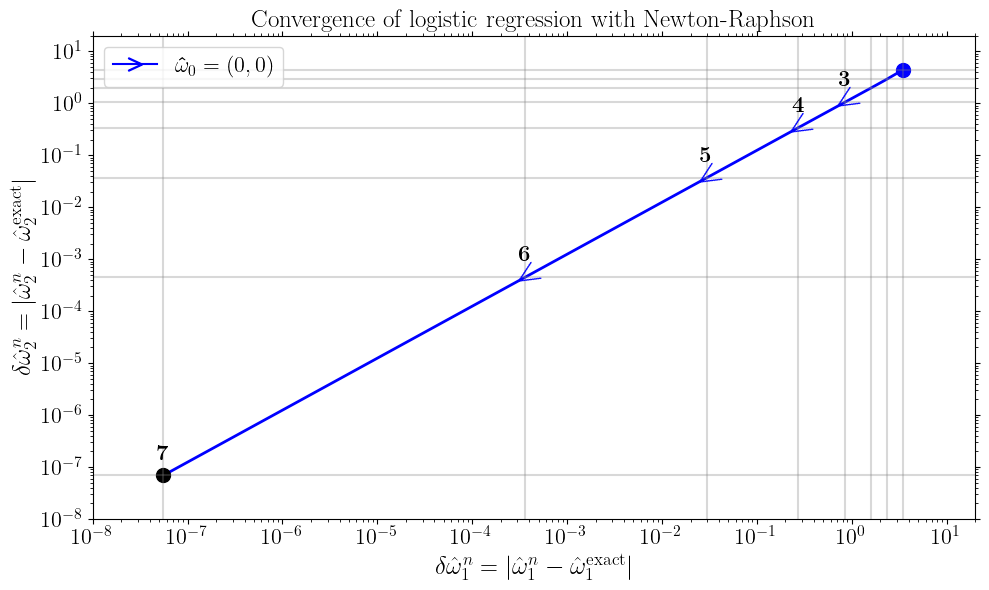

In [553]:
# --- Define data --- 
n_iter = len(omegas_newton0)
omegaerrorEvolution0 = error_evolution0
omegaerrorEvolutionp1 = error_evolutionp1
omegaerrorEvolutionm1 = error_evolutionm1

# --- Create custom major tick arrays (you can adjust these as desired) ---
x_major_ticks = np.logspace(-8, 1, 10)
y_major_ticks = np.logspace(-8, 1, 10)

# --- Create custom minor tick arrays (you can adjust these as desired) ---
x_minor_ticks = x_major_ticks.tolist()
for i in range(2, 10):
    x_minor_ticks = x_minor_ticks+(i*x_major_ticks).tolist()
x_minor_ticks = np.sort(x_minor_ticks)[:-7]
y_minor_ticks = y_major_ticks.tolist()
for i in range(2, 10):
    y_minor_ticks = y_minor_ticks+(i*y_major_ticks).tolist()
y_minor_ticks = np.sort(y_minor_ticks)[:-7]

#x_major_ticks = x_major_ticks[:-1]
#y_major_ticks = y_major_ticks[:-1]

# Enable LaTeX rendering for text
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['text.latex.preamble'] = r"""\usepackage{amsmath}
\usepackage{amsfonts}
\usepackage{amssymb}
\usepackage{bm}"""

# --- Create the figure and axis ---
fig, ax = plt.subplots(figsize=(10, 6))

# Set log scales
ax.set_xscale('log')
ax.set_yscale('log')

# Set plot range
ax.set_xlim(1e-8, 8)
ax.set_ylim(1e-8, 8)

# --- Plot the first evolution with a solid line and markers ---
line_0, = ax.loglog(omegaerrorEvolution0[:, 0], omegaerrorEvolution0[:, 1],
                  color='blue', 
                  linestyle="-",#(0, (5, 5)), 
                  linewidth=2,
                  #marker='o', markersize=7, 
                  label=r'$\mathbf{\hat\omega}_{0} = (0,0)$')

# --- Annotate the first few iterations of omegaEvolution0 ---
for i in range(3,8):
    x_val, y_val = omegaerrorEvolution0[i, 0], omegaerrorEvolution0[i, 1]
    # Place a text annotation below the point; adjust offset as needed.
    ax.text(x_val, y_val * 4, r'$\mathbf{' + str(i) + '}$', fontsize=16, color='black',
            ha='center', va='top')
    if i < 7:   
        ax.text(x_val, y_val, r'$>$', fontsize=26, rotation=180+32,
                ha='center', va='center', color='blue')

# --- Customize axes ---
ax.set_xlabel(r'$\delta\hat\omega_{1}^{n} = \left|\hat\omega_{1}^{n}-\hat\omega_{1}^{\text{exact}}\right|$', fontsize=18)
ax.set_ylabel(r'$\delta\hat\omega_{2}^{n} = \left|\hat\omega_{2}^{n}-\hat\omega_{2}^{\text{exact}}\right|$', fontsize=18)

# Create a custom legend handle for the first evolution that shows the rotated ">" marker.
# Since there's no built-in rotated marker, we can simulate it using a Line2D object.
custom_handle = Line2D([], [], color='blue', linestyle="-",
                       marker=r'$>$', markersize=10, label=r'$\mathbf{\hat\omega}_{0} = (0,0)$')

# Combine the handles: for the first evolution, use our custom_handle;
# for the others, use the handles returned by ax.plot.
handles = [custom_handle]

# Create the legend with our custom handles.
ax.legend(handles=handles, loc='upper left', fontsize=16)

ax.loglog(omegaerrorEvolution0[0, 0], omegaerrorEvolution0[0, 1],
        marker='o', markersize=10, color='blue')
ax.loglog(omegaerrorEvolution0[-1, 0], omegaerrorEvolution0[-1, 1],
        marker='o', markersize=10, color='black')

ax.set_xticks(x_major_ticks)
ax.set_xticks(x_minor_ticks, minor=True)
ax.set_yticks(y_major_ticks)
ax.set_yticks(y_minor_ticks, minor=True)
# Using tick_params:
ax.tick_params(axis='x', which='both', top=True, bottom=True, labelsize=16)
ax.tick_params(axis='y', which='both', left=True, right=True, labelsize=16)

# Draw vertical lines at x_coords and horizontal lines at y_coords
ax.vlines(omegaerrorEvolution0[:,0], ymin=ax.get_ylim()[0], ymax=ax.get_ylim()[1],
          colors='gray', linestyles='-', alpha=0.3)
ax.hlines(omegaerrorEvolution0[:,1], xmin=ax.get_xlim()[0], xmax=ax.get_xlim()[1],
          colors='gray', linestyles='-', alpha=0.3)

plt.title(f'Convergence of logistic regression with Newton-Raphson', fontsize = 18)

plt.tight_layout()

# --- Save the figure as a PDF (adjust the path as needed) ---
plt.savefig(f'/Users/rtorre/Dropbox/Apps/Overleaf/ML Methods for Physics/Figures/Chapter_3/logistic_newton_2.pdf')
plt.show()

### Gradient descent

In [614]:
# Define the GD method.
def gradient_descent(X: np.ndarray,
                        p: np.ndarray,
                        omega_init: np.ndarray,
                        threshold: float = 0.5, 
                        learning_rate: float = 0.1,
                        tol: float = 1e-6,
                        max_iter: int = 100
                        ) -> Tuple[np.ndarray, List[float]]:
        """Gradient descent for logistic regression.
        
        Parameters
        ----------
        X : np.ndarray
            Design matrix.
        Y : np.ndarray
            Target values.
        omega_init : np.ndarray
            Initial parameters.
        learning_rate : float, optional
            Learning rate, by default 0.1.
        tol : float, optional
            Tolerance for stopping criterion, by default 1e-6.
        max_iter : int, optional
            Maximum number of iterations, by default 100.
        
        Returns
        -------
        np.ndarray
            Optimal parameters.
        List[float]
            Loss values at each iteration.
        """
        omega = omega_init
        omegas = [omega]
        losses = [loss_fn(X, p, omega, threshold)]
        for i in range(max_iter):
            grad = grad_loss_fn(X, p, omega, threshold)
            omega = omega - learning_rate * grad
            omegas.append(omega)
            loss = loss_fn(X, p, omega, threshold)
            losses.append(loss)
            if np.linalg.norm(grad) < tol:
                break
        return np.array(omegas), np.array(losses)

#### $\alpha = 0.1$

In [615]:
# Minimize the loss using the Newton method.
omegas_GD001, losses_GD001 = gradient_descent(X_train, p_train, np.array([0.0,0.0]), learning_rate = 0.1, max_iter = 10000)
omegas_GDp101, losses_GDp101 = gradient_descent(X_train, p_train, np.array([1.0,0.0]), learning_rate = 0.1, max_iter = 10000)
omegas_GDm101, losses_GDm101 = gradient_descent(X_train, p_train, np.array([0.0,-1.0]), learning_rate = 0.1, max_iter = 10000)

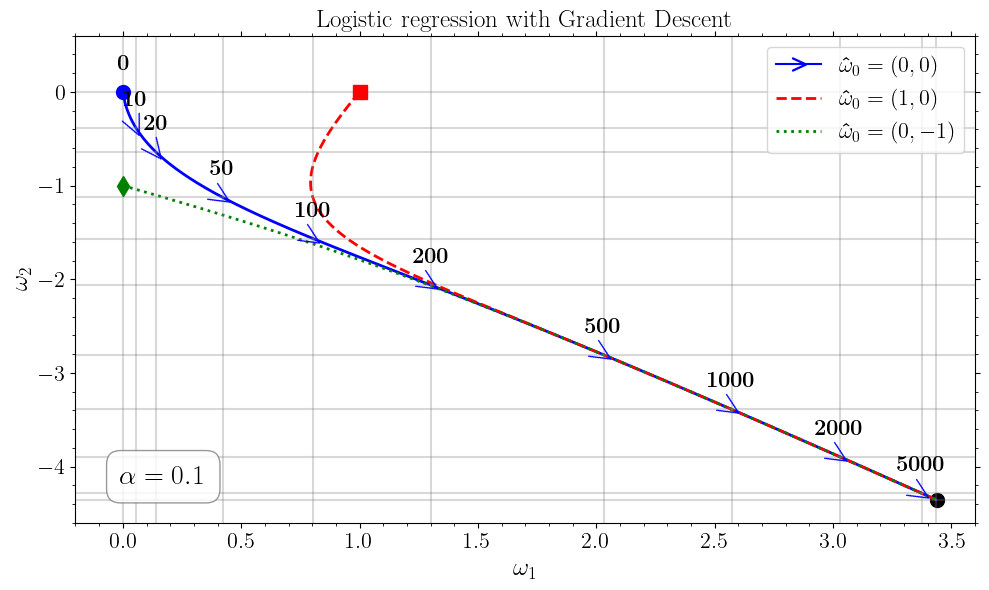

In [616]:
# --- Define data --- 
n_iter = len(omegas_GD001)
omegaEvolution0 = omegas_GD001
omegaEvolutionp1 = omegas_GDp101
omegaEvolutionm1 = omegas_GDm101

x_min, x_max = -0.2, 3.6
y_min, y_max = -4.6, 0.6

# --- Create custom tick arrays (you can adjust these as desired) ---
x_major_ticks = np.linspace(-0.5, 4, 10)
y_major_ticks = np.linspace(-5, 1, 7)

# For minor ticks, you can interpolate more finely:
x_minor_ticks = np.linspace(-0.5, 4, 46)
y_minor_ticks = np.linspace(-5, 1, 31)

# Enable LaTeX rendering for text
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['text.latex.preamble'] = r"""\usepackage{amsmath}
\usepackage{amsfonts}
\usepackage{amssymb}
\usepackage{bm}"""

# --- Create the figure and axis ---
fig, ax = plt.subplots(figsize=(10, 6))

# --- Plot the exact solution ---
line_exact, = ax.plot(exact_omega[0], exact_omega[1],
                        color='black', marker='o', markersize=10, label='Exact solution')

# --- Plot the first evolution with a solid line and markers ---
line_0, = ax.plot(omegaEvolution0[:, 0], omegaEvolution0[:, 1],
                  color='blue', 
                  linestyle="-",#(0, (5, 5)), 
                  linewidth=2,
                  #marker='o', markersize=7, 
                  label=r'$\mathbf{\hat\omega}_{0} = (0,0)$')

# --- Plot the second evolution with a dashed line and markers ---
line_p1, = ax.plot(omegaEvolutionp1[0, 0], omegaEvolutionp1[0, 1],
                   color='red', 
                   #alpha=0.6, 
                   linestyle="--", 
                   linewidth=2,
                    marker='s', markersize=7, label=r'$\mathbf{\hat\omega}_{0} = (1,0)$')

line_p1, = ax.plot(omegaEvolutionp1[:, 0], omegaEvolutionp1[:, 1],
                   color='red', 
                   #alpha=0.6, 
                   linestyle="--", 
                   linewidth=2,
                    marker=None, markersize=7, label=r'$\mathbf{\hat\omega}_{0} = (1,0)$')

# --- Plot the third evolution with a dashed line and markers ---
line_m1, = ax.plot(omegaEvolutionm1[0, 0], omegaEvolutionm1[0, 1],
                   color='green', 
                   #alpha=0.6, 
                   linestyle=":", 
                   linewidth=2,
                    marker='d', markersize=7, label=r'$\mathbf{\hat\omega}_{0} = (0,-1)$')

line_m1, = ax.plot(omegaEvolutionm1[:, 0], omegaEvolutionm1[:, 1],
                   color='green', 
                   #alpha=0.6, 
                   linestyle=":", 
                   linewidth=2,
                    marker=None, markersize=7, label=r'$\mathbf{\hat\omega}_{0} = (0,-1)$')

ax.set_xticks(x_major_ticks)
ax.set_xticks(x_minor_ticks, minor=True)
ax.set_yticks(y_major_ticks)
ax.set_yticks(y_minor_ticks, minor=True)
#ax.tick_params(axis='both', which='major', labelsize=16)
# Using tick_params:
ax.tick_params(axis='x', which='both', top=True, bottom=True, labelsize=16)
ax.tick_params(axis='y', which='both', left=True, right=True, labelsize=16)

# --- Customize axes ---
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_xlabel(r'$\omega_{1}$', fontsize=18)
ax.set_ylabel(r'$\omega_{2}$', fontsize=18)

# --- Annotate the first few iterations of omegaEvolution0 ---
#k = 0
for i in [0, 10, 20, 50, 100, 200, 500, 1000, 2000, 5000, 10000]:
    #k += 1
    x_val, y_val = omegaEvolution0[i, 0], omegaEvolution0[i, 1]
    # Place a text annotation below the point; adjust offset as needed.
    if i < 10000:
        ax.text(x_val, y_val + 0.4, r'$\mathbf{' + str(i) + '}$', fontsize=16, color='black',
                ha='center', va='top')
        if i == 10:
            ax.text(x_val, y_val, r'$>$', fontsize=26, rotation=-65,
                    ha='center', va='center', color='blue')
        if i == 20:
            ax.text(x_val, y_val, r'$>$', fontsize=26, rotation=-52,
                    ha='center', va='center', color='blue')
        if i >= 50:
            ax.text(x_val, y_val, r'$>$', fontsize=26, rotation=-32,
                    ha='center', va='center', color='blue')
    # Draw vertical lines at x_coords and horizontal lines at y_coords
    ax.vlines(omegaEvolution0[i,0], ymin=ax.get_ylim()[0], ymax=ax.get_ylim()[1],
              colors='gray', linestyles='-', alpha=0.3)
    ax.hlines(omegaEvolution0[i,1], xmin=ax.get_xlim()[0], xmax=ax.get_xlim()[1],
              colors='gray', linestyles='-', alpha=0.3)
    
plt.text(
    0.05, 0.12,
    r'$\alpha = 0.1$',
    transform=plt.gca().transAxes,  # Use axis coordinates (0,0) lower left, (1,1) upper right
    horizontalalignment='left',     # Align text to the right edge of the box
    verticalalignment='top',         # Align text to the top edge of the box
    fontsize=20,
    color='black',
    bbox=dict(facecolor='white', edgecolor='gray', alpha=0.8, boxstyle='round,pad=0.5')
)

# Create a custom legend handle for the first evolution that shows the rotated ">" marker.
# Since there's no built-in rotated marker, we can simulate it using a Line2D object.
custom_handle = Line2D([], [], color='blue', linestyle="-",
                       marker=r'$>$', markersize=10, label=r'$\mathbf{\hat\omega}_{0} = (0,0)$')

# Combine the handles: for the first evolution, use our custom_handle;
# for the others, use the handles returned by ax.plot.
handles = [custom_handle, line_p1, line_m1]

# Create the legend with our custom handles.
ax.legend(handles=handles, loc='upper right', fontsize=16)

ax.plot(omegaEvolution0[0, 0], omegaEvolution0[0, 1],
        marker='o', markersize=10, color='blue')
ax.plot(omegaEvolutionp1[0, 0], omegaEvolutionp1[0, 1],
        marker='s', markersize=10, color='red')
ax.plot(omegaEvolutionm1[0, 0], omegaEvolutionm1[0, 1],
        marker='d', markersize=10, color='green')
#ax.plot(omegaEvolution0[-1, 0], omegaEvolution0[-1, 1],
#        marker='o', markersize=10, color='red')

plt.title(f'Logistic regression with Gradient Descent', fontsize = 18)

plt.tight_layout()

# --- Save the figure as a PDF (adjust the path as needed) ---
plt.savefig(f'/Users/rtorre/Dropbox/Apps/Overleaf/ML Methods for Physics/Figures/Chapter_3/logistic_GD_alpha_01.pdf')
plt.show()

#### $\alpha = 0.5$

In [617]:
omegas_GD005, losses_GD005 = gradient_descent(X_train, p_train, np.array([0.0,0.0]), learning_rate = 0.5, max_iter = 2000)
omegas_GDp105, losses_GDp105 = gradient_descent(X_train, p_train, np.array([1.0,0.0]), learning_rate = 0.5, max_iter = 2000)
omegas_GDm105, losses_GDm105 = gradient_descent(X_train, p_train, np.array([0.0,-1.0]), learning_rate = 0.5, max_iter = 2000)

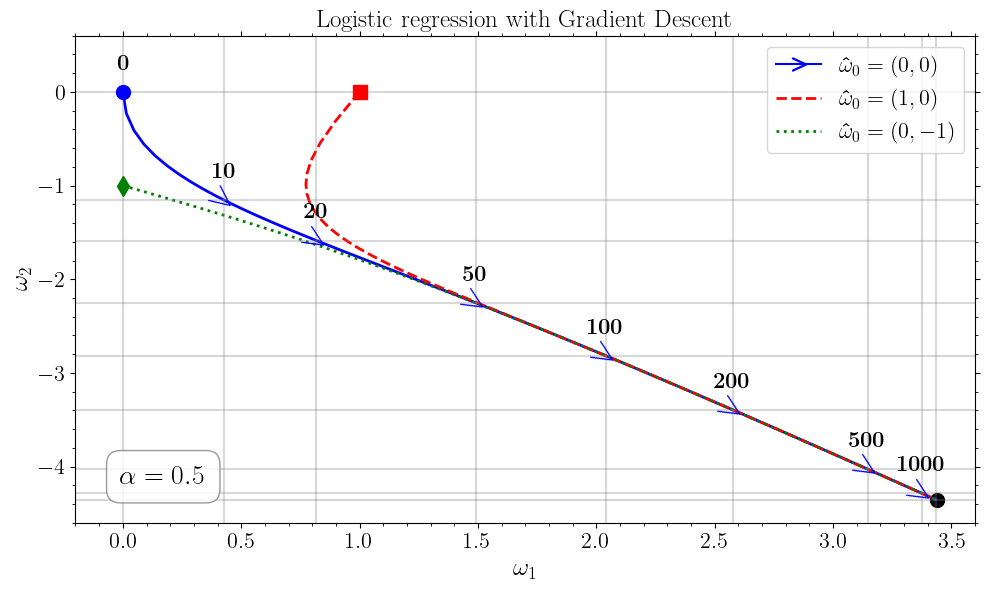

In [618]:
# --- Define data --- 
n_iter = len(omegas_GD005)
omegaEvolution0 = omegas_GD005
omegaEvolutionp1 = omegas_GDp105
omegaEvolutionm1 = omegas_GDm105

x_min, x_max = -0.2, 3.6
y_min, y_max = -4.6, 0.6

# --- Create custom tick arrays (you can adjust these as desired) ---
x_major_ticks = np.linspace(-0.5, 4, 10)
y_major_ticks = np.linspace(-5, 1, 7)

# For minor ticks, you can interpolate more finely:
x_minor_ticks = np.linspace(-0.5, 4, 46)
y_minor_ticks = np.linspace(-5, 1, 31)

# Enable LaTeX rendering for text
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['text.latex.preamble'] = r"""\usepackage{amsmath}
\usepackage{amsfonts}
\usepackage{amssymb}
\usepackage{bm}"""

# --- Create the figure and axis ---
fig, ax = plt.subplots(figsize=(10, 6))

# --- Plot the exact solution ---
line_exact, = ax.plot(exact_omega[0], exact_omega[1],
                        color='black', marker='o', markersize=10, label='Exact solution')

# --- Plot the first evolution with a solid line and markers ---
line_0, = ax.plot(omegaEvolution0[:, 0], omegaEvolution0[:, 1],
                  color='blue', 
                  linestyle="-",#(0, (5, 5)), 
                  linewidth=2,
                  #marker='o', markersize=7, 
                  label=r'$\mathbf{\hat\omega}_{0} = (0,0)$')

# --- Plot the second evolution with a dashed line and markers ---
line_p1, = ax.plot(omegaEvolutionp1[0, 0], omegaEvolutionp1[0, 1],
                   color='red', 
                   #alpha=0.6, 
                   linestyle="--", 
                   linewidth=2,
                    marker='s', markersize=7, label=r'$\mathbf{\hat\omega}_{0} = (1,0)$')

line_p1, = ax.plot(omegaEvolutionp1[:, 0], omegaEvolutionp1[:, 1],
                   color='red', 
                   #alpha=0.6, 
                   linestyle="--", 
                   linewidth=2,
                    marker=None, markersize=7, label=r'$\mathbf{\hat\omega}_{0} = (1,0)$')

# --- Plot the third evolution with a dashed line and markers ---
line_m1, = ax.plot(omegaEvolutionm1[0, 0], omegaEvolutionm1[0, 1],
                   color='green', 
                   #alpha=0.6, 
                   linestyle=":", 
                   linewidth=2,
                    marker='d', markersize=7, label=r'$\mathbf{\hat\omega}_{0} = (0,-1)$')

line_m1, = ax.plot(omegaEvolutionm1[:, 0], omegaEvolutionm1[:, 1],
                   color='green', 
                   #alpha=0.6, 
                   linestyle=":", 
                   linewidth=2,
                    marker=None, markersize=7, label=r'$\mathbf{\hat\omega}_{0} = (0,-1)$')

ax.set_xticks(x_major_ticks)
ax.set_xticks(x_minor_ticks, minor=True)
ax.set_yticks(y_major_ticks)
ax.set_yticks(y_minor_ticks, minor=True)
#ax.tick_params(axis='both', which='major', labelsize=16)
# Using tick_params:
ax.tick_params(axis='x', which='both', top=True, bottom=True, labelsize=16)
ax.tick_params(axis='y', which='both', left=True, right=True, labelsize=16)

# --- Customize axes ---
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_xlabel(r'$\omega_{1}$', fontsize=18)
ax.set_ylabel(r'$\omega_{2}$', fontsize=18)

# --- Annotate the first few iterations of omegaEvolution0 ---
#k = 0
for i in [0, 10, 20, 50, 100, 200, 500, 1000, 2000]:
    #k += 1
    x_val, y_val = omegaEvolution0[i, 0], omegaEvolution0[i, 1]
    # Place a text annotation below the point; adjust offset as needed.
    if i < 2000:
        ax.text(x_val, y_val + 0.4, r'$\mathbf{' + str(i) + '}$', fontsize=16, color='black',
                ha='center', va='top')
        if i == 10:
            ax.text(x_val, y_val, r'$>$', fontsize=26, rotation=-38,
                    ha='center', va='center', color='blue')
        if i >= 20:
            ax.text(x_val, y_val, r'$>$', fontsize=26, rotation=-32,
                    ha='center', va='center', color='blue')
    # Draw vertical lines at x_coords and horizontal lines at y_coords
    ax.vlines(omegaEvolution0[i,0], ymin=ax.get_ylim()[0], ymax=ax.get_ylim()[1],
              colors='gray', linestyles='-', alpha=0.3)
    ax.hlines(omegaEvolution0[i,1], xmin=ax.get_xlim()[0], xmax=ax.get_xlim()[1],
              colors='gray', linestyles='-', alpha=0.3)
    
plt.text(
    0.05, 0.12,
    r'$\alpha = 0.5$',
    transform=plt.gca().transAxes,  # Use axis coordinates (0,0) lower left, (1,1) upper right
    horizontalalignment='left',     # Align text to the right edge of the box
    verticalalignment='top',         # Align text to the top edge of the box
    fontsize=20,
    color='black',
    bbox=dict(facecolor='white', edgecolor='gray', alpha=0.8, boxstyle='round,pad=0.5')
)

# Create a custom legend handle for the first evolution that shows the rotated ">" marker.
# Since there's no built-in rotated marker, we can simulate it using a Line2D object.
custom_handle = Line2D([], [], color='blue', linestyle="-",
                       marker=r'$>$', markersize=10, label=r'$\mathbf{\hat\omega}_{0} = (0,0)$')

# Combine the handles: for the first evolution, use our custom_handle;
# for the others, use the handles returned by ax.plot.
handles = [custom_handle, line_p1, line_m1]

# Create the legend with our custom handles.
ax.legend(handles=handles, loc='upper right', fontsize=16)

ax.plot(omegaEvolution0[0, 0], omegaEvolution0[0, 1],
        marker='o', markersize=10, color='blue')
ax.plot(omegaEvolutionp1[0, 0], omegaEvolutionp1[0, 1],
        marker='s', markersize=10, color='red')
ax.plot(omegaEvolutionm1[0, 0], omegaEvolutionm1[0, 1],
        marker='d', markersize=10, color='green')
#ax.plot(omegaEvolution0[-1, 0], omegaEvolution0[-1, 1],
#        marker='o', markersize=10, color='red')

plt.title(f'Logistic regression with Gradient Descent', fontsize = 18)

plt.tight_layout()

# --- Save the figure as a PDF (adjust the path as needed) ---
plt.savefig(f'/Users/rtorre/Dropbox/Apps/Overleaf/ML Methods for Physics/Figures/Chapter_3/logistic_GD_alpha_05.pdf')
plt.show()

#### $\alpha = 1$

In [619]:
omegas_GD01, losses_GD01 = gradient_descent(X_train, p_train, np.array([0.0,0.0]), learning_rate = 1., max_iter = 1000)
omegas_GDp11, losses_GDp11 = gradient_descent(X_train, p_train, np.array([1.0,0.0]), learning_rate = 1., max_iter = 1000)
omegas_GDm11, losses_GDm11 = gradient_descent(X_train, p_train, np.array([0.0,-1.0]), learning_rate = 1., max_iter = 1000)

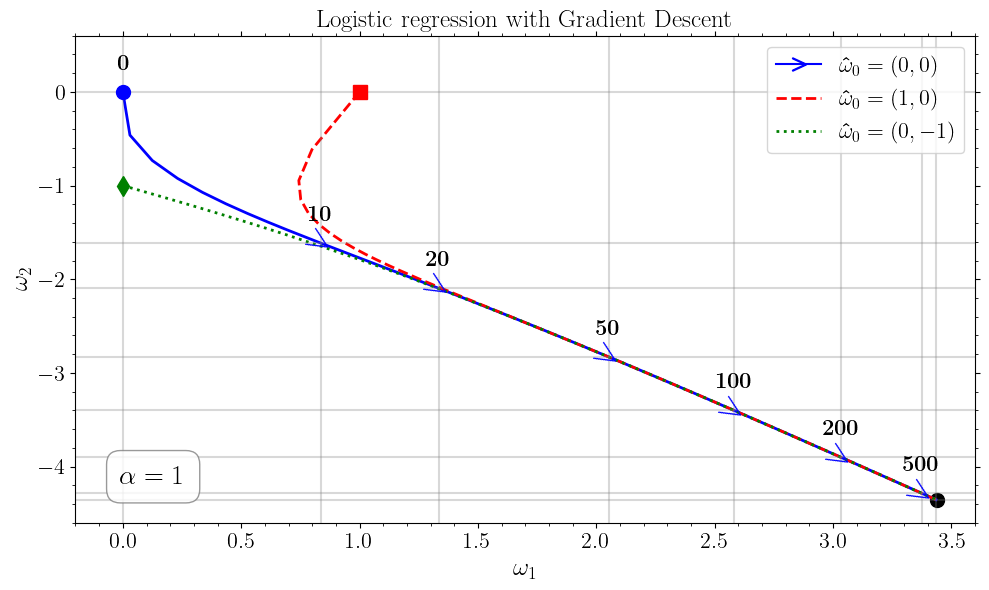

In [620]:
# --- Define data --- 
n_iter = len(omegas_GD01)
omegaEvolution0 = omegas_GD01
omegaEvolutionp1 = omegas_GDp11
omegaEvolutionm1 = omegas_GDm11

x_min, x_max = -0.2, 3.6
y_min, y_max = -4.6, 0.6

# --- Create custom tick arrays (you can adjust these as desired) ---
x_major_ticks = np.linspace(-0.5, 4, 10)
y_major_ticks = np.linspace(-5, 1, 7)

# For minor ticks, you can interpolate more finely:
x_minor_ticks = np.linspace(-0.5, 4, 46)
y_minor_ticks = np.linspace(-5, 1, 31)

# Enable LaTeX rendering for text
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['text.latex.preamble'] = r"""\usepackage{amsmath}
\usepackage{amsfonts}
\usepackage{amssymb}
\usepackage{bm}"""

# --- Create the figure and axis ---
fig, ax = plt.subplots(figsize=(10, 6))

# --- Plot the exact solution ---
line_exact, = ax.plot(exact_omega[0], exact_omega[1],
                        color='black', marker='o', markersize=10, label='Exact solution')

# --- Plot the first evolution with a solid line and markers ---
line_0, = ax.plot(omegaEvolution0[:, 0], omegaEvolution0[:, 1],
                  color='blue', 
                  linestyle="-",#(0, (5, 5)), 
                  linewidth=2,
                  #marker='o', markersize=7, 
                  label=r'$\mathbf{\hat\omega}_{0} = (0,0)$')

# --- Plot the second evolution with a dashed line and markers ---
line_p1, = ax.plot(omegaEvolutionp1[0, 0], omegaEvolutionp1[0, 1],
                   color='red', 
                   #alpha=0.6, 
                   linestyle="--", 
                   linewidth=2,
                    marker='s', markersize=7, label=r'$\mathbf{\hat\omega}_{0} = (1,0)$')

line_p1, = ax.plot(omegaEvolutionp1[:, 0], omegaEvolutionp1[:, 1],
                   color='red', 
                   #alpha=0.6, 
                   linestyle="--", 
                   linewidth=2,
                    marker=None, markersize=7, label=r'$\mathbf{\hat\omega}_{0} = (1,0)$')

# --- Plot the third evolution with a dashed line and markers ---
line_m1, = ax.plot(omegaEvolutionm1[0, 0], omegaEvolutionm1[0, 1],
                   color='green', 
                   #alpha=0.6, 
                   linestyle=":", 
                   linewidth=2,
                    marker='d', markersize=7, label=r'$\mathbf{\hat\omega}_{0} = (0,-1)$')

line_m1, = ax.plot(omegaEvolutionm1[:, 0], omegaEvolutionm1[:, 1],
                   color='green', 
                   #alpha=0.6, 
                   linestyle=":", 
                   linewidth=2,
                    marker=None, markersize=7, label=r'$\mathbf{\hat\omega}_{0} = (0,-1)$')

ax.set_xticks(x_major_ticks)
ax.set_xticks(x_minor_ticks, minor=True)
ax.set_yticks(y_major_ticks)
ax.set_yticks(y_minor_ticks, minor=True)
#ax.tick_params(axis='both', which='major', labelsize=16)
# Using tick_params:
ax.tick_params(axis='x', which='both', top=True, bottom=True, labelsize=16)
ax.tick_params(axis='y', which='both', left=True, right=True, labelsize=16)

# --- Customize axes ---
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_xlabel(r'$\omega_{1}$', fontsize=18)
ax.set_ylabel(r'$\omega_{2}$', fontsize=18)

# --- Annotate the first few iterations of omegaEvolution0 ---
#k = 0
for i in [0, 10, 20, 50, 100, 200, 500, 1000]:
    #k += 1
    x_val, y_val = omegaEvolution0[i, 0], omegaEvolution0[i, 1]
    # Place a text annotation below the point; adjust offset as needed.
    if i < 1000:
        ax.text(x_val, y_val + 0.4, r'$\mathbf{' + str(i) + '}$', fontsize=16, color='black',
                ha='center', va='top')
        if i >= 10:
            ax.text(x_val, y_val, r'$>$', fontsize=26, rotation=-32,
                    ha='center', va='center', color='blue')
    # Draw vertical lines at x_coords and horizontal lines at y_coords
    ax.vlines(omegaEvolution0[i,0], ymin=ax.get_ylim()[0], ymax=ax.get_ylim()[1],
              colors='gray', linestyles='-', alpha=0.3)
    ax.hlines(omegaEvolution0[i,1], xmin=ax.get_xlim()[0], xmax=ax.get_xlim()[1],
              colors='gray', linestyles='-', alpha=0.3)
    
plt.text(
    0.05, 0.12,
    r'$\alpha = 1$',
    transform=plt.gca().transAxes,  # Use axis coordinates (0,0) lower left, (1,1) upper right
    horizontalalignment='left',     # Align text to the right edge of the box
    verticalalignment='top',         # Align text to the top edge of the box
    fontsize=20,
    color='black',
    bbox=dict(facecolor='white', edgecolor='gray', alpha=0.8, boxstyle='round,pad=0.5')
)

# Create a custom legend handle for the first evolution that shows the rotated ">" marker.
# Since there's no built-in rotated marker, we can simulate it using a Line2D object.
custom_handle = Line2D([], [], color='blue', linestyle="-",
                       marker=r'$>$', markersize=10, label=r'$\mathbf{\hat\omega}_{0} = (0,0)$')

# Combine the handles: for the first evolution, use our custom_handle;
# for the others, use the handles returned by ax.plot.
handles = [custom_handle, line_p1, line_m1]

# Create the legend with our custom handles.
ax.legend(handles=handles, loc='upper right', fontsize=16)

ax.plot(omegaEvolution0[0, 0], omegaEvolution0[0, 1],
        marker='o', markersize=10, color='blue')
ax.plot(omegaEvolutionp1[0, 0], omegaEvolutionp1[0, 1],
        marker='s', markersize=10, color='red')
ax.plot(omegaEvolutionm1[0, 0], omegaEvolutionm1[0, 1],
        marker='d', markersize=10, color='green')
#ax.plot(omegaEvolution0[-1, 0], omegaEvolution0[-1, 1],
#        marker='o', markersize=10, color='red')

plt.title(f'Logistic regression with Gradient Descent', fontsize = 18)

plt.tight_layout()

# --- Save the figure as a PDF (adjust the path as needed) ---
plt.savefig(f'/Users/rtorre/Dropbox/Apps/Overleaf/ML Methods for Physics/Figures/Chapter_3/logistic_GD_alpha_1.pdf')
plt.show()

#### $\alpha = 5$

In [621]:
omegas_GD05, losses_GD05 = gradient_descent(X_train, p_train, np.array([0.0,0.0]), learning_rate = 5., max_iter = 200)
omegas_GDp15, losses_GDp15 = gradient_descent(X_train, p_train, np.array([1.0,0.0]), learning_rate = 5., max_iter = 200)
omegas_GDm15, losses_GDm15 = gradient_descent(X_train, p_train, np.array([0.0,-1.0]), learning_rate = 5., max_iter = 200)

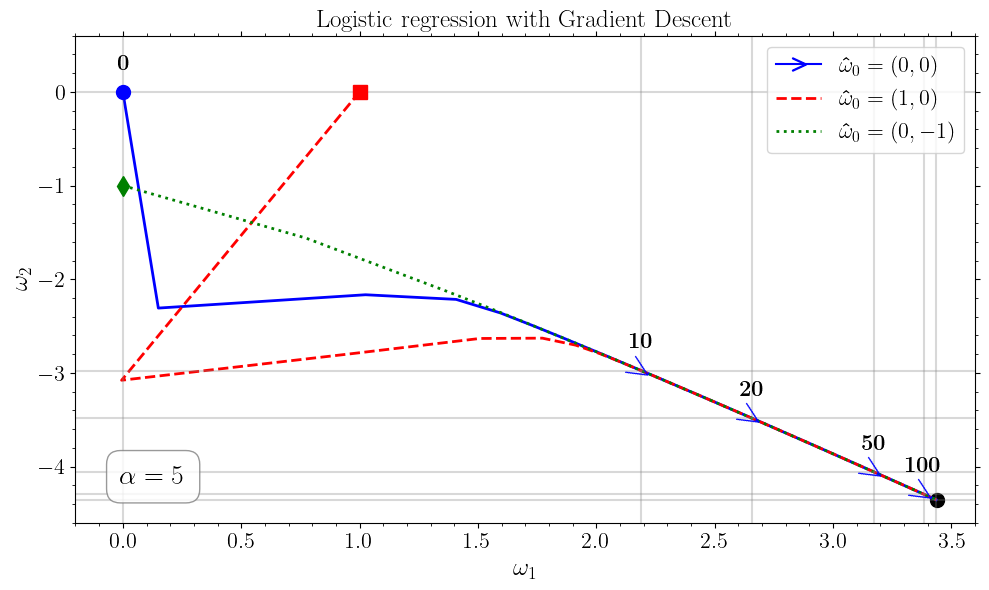

In [622]:
# --- Define data --- 
n_iter = len(omegas_GD05)
omegaEvolution0 = omegas_GD05
omegaEvolutionp1 = omegas_GDp15
omegaEvolutionm1 = omegas_GDm15

x_min, x_max = -0.2, 3.6
y_min, y_max = -4.6, 0.6

# --- Create custom tick arrays (you can adjust these as desired) ---
x_major_ticks = np.linspace(-0.5, 4, 10)
y_major_ticks = np.linspace(-5, 1, 7)

# For minor ticks, you can interpolate more finely:
x_minor_ticks = np.linspace(-0.5, 4, 46)
y_minor_ticks = np.linspace(-5, 1, 31)

# Enable LaTeX rendering for text
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['text.latex.preamble'] = r"""\usepackage{amsmath}
\usepackage{amsfonts}
\usepackage{amssymb}
\usepackage{bm}"""

# --- Create the figure and axis ---
fig, ax = plt.subplots(figsize=(10, 6))

# --- Plot the exact solution ---
line_exact, = ax.plot(exact_omega[0], exact_omega[1],
                        color='black', marker='o', markersize=10, label='Exact solution')

# --- Plot the first evolution with a solid line and markers ---
line_0, = ax.plot(omegaEvolution0[:, 0], omegaEvolution0[:, 1],
                  color='blue', 
                  linestyle="-",#(0, (5, 5)), 
                  linewidth=2,
                  #marker='o', markersize=7, 
                  label=r'$\mathbf{\hat\omega}_{0} = (0,0)$')

# --- Plot the second evolution with a dashed line and markers ---
line_p1, = ax.plot(omegaEvolutionp1[0, 0], omegaEvolutionp1[0, 1],
                   color='red', 
                   #alpha=0.6, 
                   linestyle="--", 
                   linewidth=2,
                    marker='s', markersize=7, label=r'$\mathbf{\hat\omega}_{0} = (1,0)$')

line_p1, = ax.plot(omegaEvolutionp1[:, 0], omegaEvolutionp1[:, 1],
                   color='red', 
                   #alpha=0.6, 
                   linestyle="--", 
                   linewidth=2,
                    marker=None, markersize=7, label=r'$\mathbf{\hat\omega}_{0} = (1,0)$')

# --- Plot the third evolution with a dashed line and markers ---
line_m1, = ax.plot(omegaEvolutionm1[0, 0], omegaEvolutionm1[0, 1],
                   color='green', 
                   #alpha=0.6, 
                   linestyle=":", 
                   linewidth=2,
                    marker='d', markersize=7, label=r'$\mathbf{\hat\omega}_{0} = (0,-1)$')

line_m1, = ax.plot(omegaEvolutionm1[:, 0], omegaEvolutionm1[:, 1],
                   color='green', 
                   #alpha=0.6, 
                   linestyle=":", 
                   linewidth=2,
                    marker=None, markersize=7, label=r'$\mathbf{\hat\omega}_{0} = (0,-1)$')

ax.set_xticks(x_major_ticks)
ax.set_xticks(x_minor_ticks, minor=True)
ax.set_yticks(y_major_ticks)
ax.set_yticks(y_minor_ticks, minor=True)
#ax.tick_params(axis='both', which='major', labelsize=16)
# Using tick_params:
ax.tick_params(axis='x', which='both', top=True, bottom=True, labelsize=16)
ax.tick_params(axis='y', which='both', left=True, right=True, labelsize=16)

# --- Customize axes ---
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_xlabel(r'$\omega_{1}$', fontsize=18)
ax.set_ylabel(r'$\omega_{2}$', fontsize=18)

# --- Annotate the first few iterations of omegaEvolution0 ---
#k = 0
for i in [0, 10, 20, 50, 100, 200]:
    #k += 1
    x_val, y_val = omegaEvolution0[i, 0], omegaEvolution0[i, 1]
    # Place a text annotation below the point; adjust offset as needed.
    if i < 200:
        ax.text(x_val, y_val + 0.4, r'$\mathbf{' + str(i) + '}$', fontsize=16, color='black',
                ha='center', va='top')
        if i >= 10:
            ax.text(x_val, y_val, r'$>$', fontsize=26, rotation=-32,
                    ha='center', va='center', color='blue')
    # Draw vertical lines at x_coords and horizontal lines at y_coords
    ax.vlines(omegaEvolution0[i,0], ymin=ax.get_ylim()[0], ymax=ax.get_ylim()[1],
              colors='gray', linestyles='-', alpha=0.3)
    ax.hlines(omegaEvolution0[i,1], xmin=ax.get_xlim()[0], xmax=ax.get_xlim()[1],
              colors='gray', linestyles='-', alpha=0.3)
    
plt.text(
    0.05, 0.12,
    r'$\alpha = 5$',
    transform=plt.gca().transAxes,  # Use axis coordinates (0,0) lower left, (1,1) upper right
    horizontalalignment='left',     # Align text to the right edge of the box
    verticalalignment='top',         # Align text to the top edge of the box
    fontsize=20,
    color='black',
    bbox=dict(facecolor='white', edgecolor='gray', alpha=0.8, boxstyle='round,pad=0.5')
)

# Create a custom legend handle for the first evolution that shows the rotated ">" marker.
# Since there's no built-in rotated marker, we can simulate it using a Line2D object.
custom_handle = Line2D([], [], color='blue', linestyle="-",
                       marker=r'$>$', markersize=10, label=r'$\mathbf{\hat\omega}_{0} = (0,0)$')

# Combine the handles: for the first evolution, use our custom_handle;
# for the others, use the handles returned by ax.plot.
handles = [custom_handle, line_p1, line_m1]

# Create the legend with our custom handles.
ax.legend(handles=handles, loc='upper right', fontsize=16)

ax.plot(omegaEvolution0[0, 0], omegaEvolution0[0, 1],
        marker='o', markersize=10, color='blue')
ax.plot(omegaEvolutionp1[0, 0], omegaEvolutionp1[0, 1],
        marker='s', markersize=10, color='red')
ax.plot(omegaEvolutionm1[0, 0], omegaEvolutionm1[0, 1],
        marker='d', markersize=10, color='green')
#ax.plot(omegaEvolution0[-1, 0], omegaEvolution0[-1, 1],
#        marker='o', markersize=10, color='red')

plt.title(f'Logistic regression with Gradient Descent', fontsize = 18)

plt.tight_layout()

# --- Save the figure as a PDF (adjust the path as needed) ---
plt.savefig(f'/Users/rtorre/Dropbox/Apps/Overleaf/ML Methods for Physics/Figures/Chapter_3/logistic_GD_alpha_5.pdf')
plt.show()

#### $\alpha = 10$

In [623]:
omegas_GD010, losses_GD010 = gradient_descent(X_train, p_train, np.array([0.0,0.0]), learning_rate = 10., max_iter = 100)
omegas_GDp110, losses_GDp110 = gradient_descent(X_train, p_train, np.array([1.0,0.0]), learning_rate = 10., max_iter = 100)
omegas_GDm110, losses_GDm110 = gradient_descent(X_train, p_train, np.array([0.0,-1.0]), learning_rate = 10., max_iter = 100)

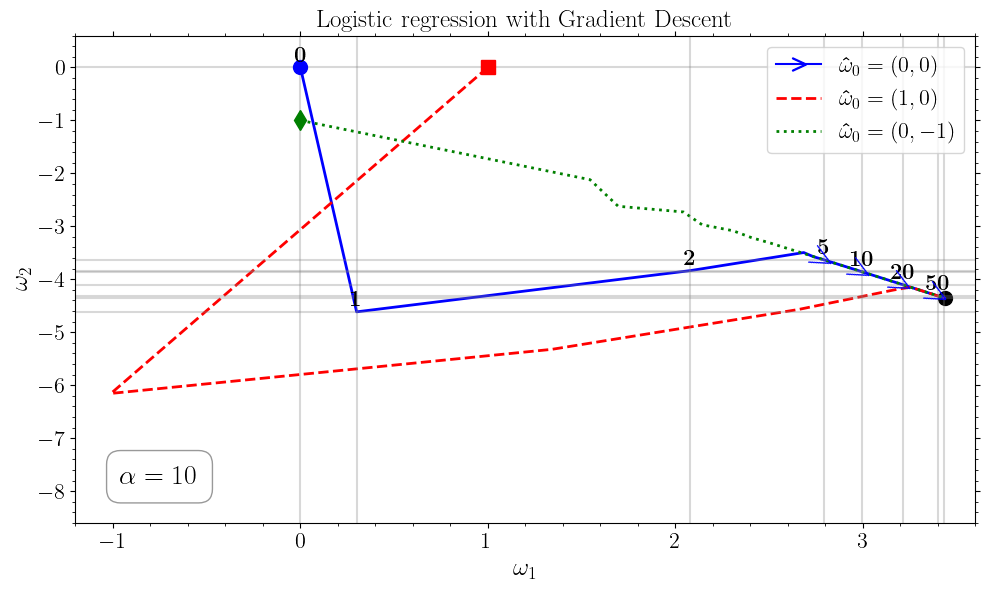

In [624]:
# --- Define data --- 
n_iter = len(omegas_GD010)
omegaEvolution0 = omegas_GD010
omegaEvolutionp1 = omegas_GDp110
omegaEvolutionm1 = omegas_GDm110

x_min, x_max = -1.2, 3.6
y_min, y_max = -8.6, 0.6

# --- Create custom tick arrays (you can adjust these as desired) ---
x_major_ticks = np.linspace(-5, 4, 10)
y_major_ticks = np.linspace(-9, 1, 11)

# For minor ticks, you can interpolate more finely:
x_minor_ticks = np.linspace(-5, 4, 46)
y_minor_ticks = np.linspace(-9, 1, 51)

# Enable LaTeX rendering for text
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['text.latex.preamble'] = r"""\usepackage{amsmath}
\usepackage{amsfonts}
\usepackage{amssymb}
\usepackage{bm}"""

# --- Create the figure and axis ---
fig, ax = plt.subplots(figsize=(10, 6))

# --- Plot the exact solution ---
line_exact, = ax.plot(exact_omega[0], exact_omega[1],
                        color='black', marker='o', markersize=10, label='Exact solution')

# --- Plot the first evolution with a solid line and markers ---
line_0, = ax.plot(omegaEvolution0[:, 0], omegaEvolution0[:, 1],
                  color='blue', 
                  linestyle="-",#(0, (5, 5)), 
                  linewidth=2,
                  #marker='o', markersize=7, 
                  label=r'$\mathbf{\hat\omega}_{0} = (0,0)$')

# --- Plot the second evolution with a dashed line and markers ---
line_p1, = ax.plot(omegaEvolutionp1[0, 0], omegaEvolutionp1[0, 1],
                   color='red', 
                   #alpha=0.6, 
                   linestyle="--", 
                   linewidth=2,
                    marker='s', markersize=7, label=r'$\mathbf{\hat\omega}_{0} = (1,0)$')

line_p1, = ax.plot(omegaEvolutionp1[:, 0], omegaEvolutionp1[:, 1],
                   color='red', 
                   #alpha=0.6, 
                   linestyle="--", 
                   linewidth=2,
                    marker=None, markersize=7, label=r'$\mathbf{\hat\omega}_{0} = (1,0)$')

# --- Plot the third evolution with a dashed line and markers ---
line_m1, = ax.plot(omegaEvolutionm1[0, 0], omegaEvolutionm1[0, 1],
                   color='green', 
                   #alpha=0.6, 
                   linestyle=":", 
                   linewidth=2,
                    marker='d', markersize=7, label=r'$\mathbf{\hat\omega}_{0} = (0,-1)$')

line_m1, = ax.plot(omegaEvolutionm1[:, 0], omegaEvolutionm1[:, 1],
                   color='green', 
                   #alpha=0.6, 
                   linestyle=":", 
                   linewidth=2,
                    marker=None, markersize=7, label=r'$\mathbf{\hat\omega}_{0} = (0,-1)$')

ax.set_xticks(x_major_ticks)
ax.set_xticks(x_minor_ticks, minor=True)
ax.set_yticks(y_major_ticks)
ax.set_yticks(y_minor_ticks, minor=True)
#ax.tick_params(axis='both', which='major', labelsize=16)
# Using tick_params:
ax.tick_params(axis='x', which='both', top=True, bottom=True, labelsize=16)
ax.tick_params(axis='y', which='both', left=True, right=True, labelsize=16)

# --- Customize axes ---
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_xlabel(r'$\omega_{1}$', fontsize=18)
ax.set_ylabel(r'$\omega_{2}$', fontsize=18)

# --- Annotate the first few iterations of omegaEvolution0 ---
#k = 0
for i in [0, 1, 2, 5, 10, 20, 50, 100]:
    #k += 1
    x_val, y_val = omegaEvolution0[i, 0], omegaEvolution0[i, 1]
    # Place a text annotation below the point; adjust offset as needed.
    if i < 100:
        ax.text(x_val, y_val + 0.4, r'$\mathbf{' + str(i) + '}$', fontsize=16, color='black',
                ha='center', va='top')
        if i >= 5:
            ax.text(x_val, y_val, r'$>$', fontsize=26, rotation=-28,
                    ha='center', va='center', color='blue')
    # Draw vertical lines at x_coords and horizontal lines at y_coords
    ax.vlines(omegaEvolution0[i,0], ymin=ax.get_ylim()[0], ymax=ax.get_ylim()[1],
              colors='gray', linestyles='-', alpha=0.3)
    ax.hlines(omegaEvolution0[i,1], xmin=ax.get_xlim()[0], xmax=ax.get_xlim()[1],
              colors='gray', linestyles='-', alpha=0.3)
    
plt.text(
    0.05, 0.12,
    r'$\alpha = 10$',
    transform=plt.gca().transAxes,  # Use axis coordinates (0,0) lower left, (1,1) upper right
    horizontalalignment='left',     # Align text to the right edge of the box
    verticalalignment='top',         # Align text to the top edge of the box
    fontsize=20,
    color='black',
    bbox=dict(facecolor='white', edgecolor='gray', alpha=0.8, boxstyle='round,pad=0.5')
)

# Create a custom legend handle for the first evolution that shows the rotated ">" marker.
# Since there's no built-in rotated marker, we can simulate it using a Line2D object.
custom_handle = Line2D([], [], color='blue', linestyle="-",
                       marker=r'$>$', markersize=10, label=r'$\mathbf{\hat\omega}_{0} = (0,0)$')

# Combine the handles: for the first evolution, use our custom_handle;
# for the others, use the handles returned by ax.plot.
handles = [custom_handle, line_p1, line_m1]

# Create the legend with our custom handles.
ax.legend(handles=handles, loc='upper right', fontsize=16)

ax.plot(omegaEvolution0[0, 0], omegaEvolution0[0, 1],
        marker='o', markersize=10, color='blue')
ax.plot(omegaEvolutionp1[0, 0], omegaEvolutionp1[0, 1],
        marker='s', markersize=10, color='red')
ax.plot(omegaEvolutionm1[0, 0], omegaEvolutionm1[0, 1],
        marker='d', markersize=10, color='green')
#ax.plot(omegaEvolution0[-1, 0], omegaEvolution0[-1, 1],
#        marker='o', markersize=10, color='red')

plt.title(f'Logistic regression with Gradient Descent', fontsize = 18)

plt.tight_layout()

# --- Save the figure as a PDF (adjust the path as needed) ---
plt.savefig(f'/Users/rtorre/Dropbox/Apps/Overleaf/ML Methods for Physics/Figures/Chapter_3/logistic_GD_alpha_10.pdf')
plt.show()

#### Convergence

In [699]:
res03 = []
for lr in [0.05, 0.1, 0.2, 0.5, 1., 2., 5., 10., 20.]:
    omegas_GD0, losses_GD0 = gradient_descent(X_train, p_train, np.array([0.0,0.0]), learning_rate = lr, max_iter = 100000, tol = 1e-10)
    tmp = [[lr, i, np.sqrt(np.sum((omegas_GD0[i]-exact_omega)**2)),np.sqrt(np.sum((omegas_GD0[i]-exact_omega)**2))<1e-03] for i in range(len(omegas_GD0)) if np.sqrt(np.sum((omegas_GD0[i]-exact_omega)**2))<1e-03][0]
    res03.append([tmp[0], tmp[1]])
    print(f'For alpha = {lr}, the algorithm converges to the exact solution after {tmp[1]} iterations, with a distance of {tmp[2]}')
res03 = np.array(res03)

For alpha = 0.05, the algorithm converges to the exact solution after 25654 iterations, with a distance of 0.0009998306072864062
For alpha = 0.1, the algorithm converges to the exact solution after 12824 iterations, with a distance of 0.0009999891633932277
For alpha = 0.2, the algorithm converges to the exact solution after 6410 iterations, with a distance of 0.0009991443487633418
For alpha = 0.5, the algorithm converges to the exact solution after 2561 iterations, with a distance of 0.00099831809678094
For alpha = 1.0, the algorithm converges to the exact solution after 1278 iterations, with a distance of 0.0009968308861095913
For alpha = 2.0, the algorithm converges to the exact solution after 636 iterations, with a distance of 0.0009990098657792629
For alpha = 5.0, the algorithm converges to the exact solution after 251 iterations, with a distance of 0.0009797430195272753
For alpha = 10.0, the algorithm converges to the exact solution after 116 iterations, with a distance of 0.00099

In [701]:
res05 = []
for lr in [0.05, 0.1, 0.2, 0.5, 1., 2., 5., 10., 20.]:
    omegas_GD0, losses_GD0 = gradient_descent(X_train, p_train, np.array([0.0,0.0]), learning_rate = lr, max_iter = 100000, tol = 1e-10)
    tmp = [[lr, i, np.sqrt(np.sum((omegas_GD0[i]-exact_omega)**2)),np.sqrt(np.sum((omegas_GD0[i]-exact_omega)**2))<1e-05] for i in range(len(omegas_GD0)) if np.sqrt(np.sum((omegas_GD0[i]-exact_omega)**2))<1e-05][0]
    res05.append([tmp[0], tmp[1]])
    print(f'For alpha = {lr}, the algorithm converges to the exact solution after {tmp[1]} iterations, with a distance of {tmp[2]}')
res05 = np.array(res05)

For alpha = 0.05, the algorithm converges to the exact solution after 41557 iterations, with a distance of 9.999580142869224e-06
For alpha = 0.1, the algorithm converges to the exact solution after 20775 iterations, with a distance of 9.99739236701716e-06
For alpha = 0.2, the algorithm converges to the exact solution after 10384 iterations, with a distance of 9.992980066505306e-06
For alpha = 0.5, the algorithm converges to the exact solution after 4149 iterations, with a distance of 9.991016316968784e-06
For alpha = 1.0, the algorithm converges to the exact solution after 2071 iterations, with a distance of 9.967286315663372e-06
For alpha = 2.0, the algorithm converges to the exact solution after 1032 iterations, with a distance of 9.913176799913122e-06
For alpha = 5.0, the algorithm converges to the exact solution after 408 iterations, with a distance of 9.723911328842758e-06
For alpha = 10.0, the algorithm converges to the exact solution after 194 iterations, with a distance of 9.52

In [702]:
res07 = []
for lr in [0.05, 0.1, 0.2, 0.5, 1., 2., 5., 10., 20.]:
    omegas_GD0, losses_GD0 = gradient_descent(X_train, p_train, np.array([0.0,0.0]), learning_rate = lr, max_iter = 100000, tol = 1e-10)
    tmp = [[lr, i, np.sqrt(np.sum((omegas_GD0[i]-exact_omega)**2)),np.sqrt(np.sum((omegas_GD0[i]-exact_omega)**2))<1e-07] for i in range(len(omegas_GD0)) if np.sqrt(np.sum((omegas_GD0[i]-exact_omega)**2))<1e-07][0]
    res07.append([tmp[0], tmp[1]])
    print(f'For alpha = {lr}, the algorithm converges to the exact solution after {tmp[1]} iterations, with a distance of {tmp[2]}')
res07 = np.array(res07)

For alpha = 0.05, the algorithm converges to the exact solution after 57462 iterations, with a distance of 9.997554367785493e-08
For alpha = 0.1, the algorithm converges to the exact solution after 28726 iterations, with a distance of 9.997383768624084e-08
For alpha = 0.2, the algorithm converges to the exact solution after 14358 iterations, with a distance of 9.997007468716473e-08
For alpha = 0.5, the algorithm converges to the exact solution after 5738 iterations, with a distance of 9.972396264162706e-08
For alpha = 1.0, the algorithm converges to the exact solution after 2864 iterations, with a distance of 9.968752904271182e-08
For alpha = 2.0, the algorithm converges to the exact solution after 1427 iterations, with a distance of 9.954603177211134e-08
For alpha = 5.0, the algorithm converges to the exact solution after 564 iterations, with a distance of 9.941179576876955e-08
For alpha = 10.0, the algorithm converges to the exact solution after 271 iterations, with a distance of 9.6

In [703]:
res10 = []
for lr in [0.05, 0.1, 0.2, 0.5, 1., 2., 5., 10., 20.]:
    omegas_GD0, losses_GD0 = gradient_descent(X_train, p_train, np.array([0.0,0.0]), learning_rate = lr, max_iter = 100000, tol = 1e-15)
    tmp = [[lr, i, np.sqrt(np.sum((omegas_GD0[i]-exact_omega)**2)),np.sqrt(np.sum((omegas_GD0[i]-exact_omega)**2))<1e-10] for i in range(len(omegas_GD0)) if np.sqrt(np.sum((omegas_GD0[i]-exact_omega)**2))<1e-10][0]
    res10.append([tmp[0], tmp[1]])
    print(f'For alpha = {lr}, the algorithm converges to the exact solution after {tmp[1]} iterations, with a distance of {tmp[2]}')
res10 = np.array(res10)

For alpha = 0.05, the algorithm converges to the exact solution after 81319 iterations, with a distance of 9.999511723693972e-11
For alpha = 0.1, the algorithm converges to the exact solution after 40653 iterations, with a distance of 9.995884024809671e-11
For alpha = 0.2, the algorithm converges to the exact solution after 20320 iterations, with a distance of 9.991126118174203e-11
For alpha = 0.5, the algorithm converges to the exact solution after 8120 iterations, with a distance of 9.987821633921674e-11
For alpha = 1.0, the algorithm converges to the exact solution after 4053 iterations, with a distance of 9.999815323971936e-11
For alpha = 2.0, the algorithm converges to the exact solution after 2020 iterations, with a distance of 9.95868653904771e-11
For alpha = 5.0, the algorithm converges to the exact solution after 799 iterations, with a distance of 9.978572210485071e-11
For alpha = 10.0, the algorithm converges to the exact solution after 387 iterations, with a distance of 9.53

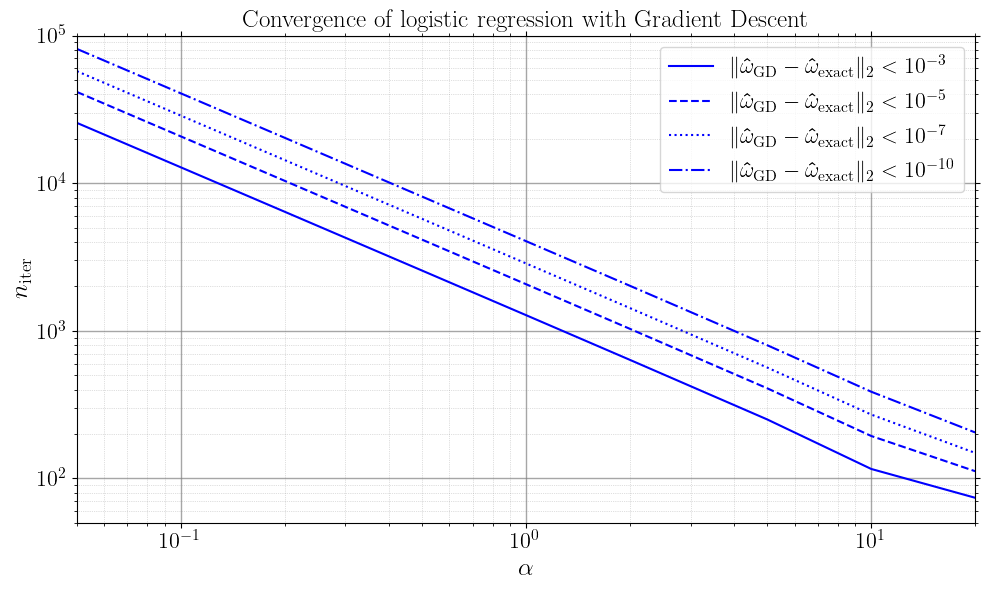

In [698]:
# Enable LaTeX rendering for text
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['text.latex.preamble'] = r"""\usepackage{amsmath}
\usepackage{amsfonts}
\usepackage{amssymb}
\usepackage{bm}"""

# --- Create the figure and axis ---
fig, ax = plt.subplots(figsize=(10, 6))

# Set log scales
ax.set_xscale('log')
ax.set_yscale('log')

# Set plot range
ax.set_xlim(0.05, 20)
ax.set_ylim(50, 100000)

# --- Plot the exact solution ---
ax.loglog(res03[:,0], res03[:,1],
    color='blue', linestyle = "-", markersize=10, label=r'$\| \mathbf{\hat\omega}_{\text{GD}} - \mathbf{\hat\omega}_{\text{exact}} \|_{2} < 10^{-3}$')
ax.loglog(res05[:,0], res05[:,1],
    color='blue', linestyle = "--", label=r'$\| \mathbf{\hat\omega}_{\text{GD}} - \mathbf{\hat\omega}_{\text{exact}} \|_{2} < 10^{-5}$')
ax.loglog(res07[:,0], res07[:,1],
    color='blue', linestyle = ":", label=r'$\| \mathbf{\hat\omega}_{\text{GD}} - \mathbf{\hat\omega}_{\text{exact}} \|_{2} < 10^{-7}$')
ax.loglog(res10[:,0], res10[:,1],
    color='blue', linestyle = "-.", label=r'$\| \mathbf{\hat\omega}_{\text{GD}} - \mathbf{\hat\omega}_{\text{exact}} \|_{2} < 10^{-10}$')

# --- Customize axes ---
ax.set_xlabel(r'$\alpha$', fontsize=18)
ax.set_ylabel(r'$n_{\text{iter}}$', fontsize=18)

# Create the legend with our custom handles.
ax.legend(loc='upper right', fontsize=16)

# Using tick_params:
ax.tick_params(axis='x', which='both', top=True, bottom=True, labelsize=16)
ax.tick_params(axis='y', which='both', left=True, right=True, labelsize=16)

# Draw vertical lines at x_coords and horizontal lines at y_coords
ax.grid(which='minor', linestyle=':', linewidth=0.5, color='gray', alpha=0.5)
ax.grid(which='major', linestyle='-', linewidth=1, color='gray', alpha=0.7)

plt.title(f'Convergence of logistic regression with Gradient Descent', fontsize = 18)

plt.tight_layout()

# --- Save the figure as a PDF (adjust the path as needed) ---
plt.savefig(f'/Users/rtorre/Dropbox/Apps/Overleaf/ML Methods for Physics/Figures/Chapter_3/logistic_GD_convergence.pdf')

plt.show()

### Adam

In [630]:
# Define the Adam optimizer.
def adam(X: np.ndarray,
            p: np.ndarray,
            omega_init: np.ndarray,
            threshold: float = 0.5,
            learning_rate: float = 0.1,
            beta1: float = 0.9,
            beta2: float = 0.999,
            tol: float = 1e-6,
            max_iter: int = 100
            ) -> Tuple[np.ndarray, List[float]]:
    """Adam optimizer for logistic regression.
    
    Parameters
    ----------
    X : np.ndarray
        Design matrix.
    Y : np.ndarray
        Target values.
    omega_init : np.ndarray
        Initial parameters.
    learning_rate : float, optional
        Learning rate, by default 0.1.
    beta1 : float, optional
        Exponential decay rate for the first moment estimates, by default 0.9.
    beta2 : float, optional
        Exponential decay rate for the second moment estimates, by default 0.999.
    tol : float, optional
        Tolerance for stopping criterion, by default 1e-6.
    max_iter : int, optional
        Maximum number of iterations, by default 100.
    
    Returns
    -------
    np.ndarray
        Optimal parameters.
    List[float]
        Loss values at each iteration.
    """
    omega = omega_init
    m = np.zeros_like(omega)
    v = np.zeros_like(omega)
    omegas = [omega]
    losses = [loss_fn(X, p, omega, threshold)]
    for i in range(max_iter):
        grad = grad_loss_fn(X, p, omega, threshold)
        m = beta1 * m + (1 - beta1) * grad
        v = beta2 * v + (1 - beta2) * grad**2
        m_hat = m / (1 - beta1**(i + 1))
        v_hat = v / (1 - beta2**(i + 1))
        omega = omega - learning_rate * m_hat / (np.sqrt(v_hat) + tol)
        omegas.append(omega)
        loss = loss_fn(X, p, omega, threshold)
        losses.append(loss)
        if np.linalg.norm(grad) < tol:
            break
    return np.array(omegas), np.array(losses)

#### $\alpha = 0.01$

In [655]:
# Minimize the loss using the Newton method.
omegas_Adam0001, losses_Adam0001 = adam(X_train, p_train, np.array([0.0,0.0]), learning_rate = 0.01, max_iter = 10000)
omegas_Adamp1001, losses_Adamp1001 = adam(X_train, p_train, np.array([1.0,0.0]), learning_rate = 0.01, max_iter = 10000)
omegas_Adamm1001, losses_Adamm1001 = adam(X_train, p_train, np.array([0.0,-1.0]), learning_rate = 0.01, max_iter = 10000)

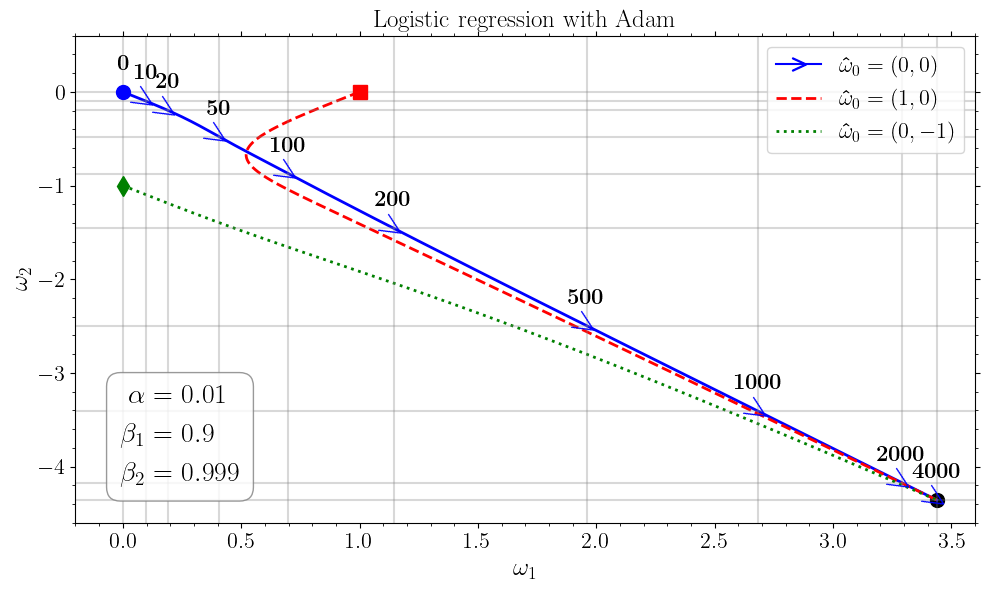

In [656]:
# --- Define data --- 
n_iter = len(omegas_Adam0001)
omegaEvolution0 = omegas_Adam0001
omegaEvolutionp1 = omegas_Adamp1001
omegaEvolutionm1 = omegas_Adamm1001

x_min, x_max = -0.2, 3.6
y_min, y_max = -4.6, 0.6

# --- Create custom tick arrays (you can adjust these as desired) ---
x_major_ticks = np.linspace(-0.5, 4, 10)
y_major_ticks = np.linspace(-5, 1, 7)

# For minor ticks, you can interpolate more finely:
x_minor_ticks = np.linspace(-0.5, 4, 46)
y_minor_ticks = np.linspace(-5, 1, 31)

# Enable LaTeX rendering for text
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['text.latex.preamble'] = r"""\usepackage{amsmath}
\usepackage{amsfonts}
\usepackage{amssymb}
\usepackage{bm}"""

# --- Create the figure and axis ---
fig, ax = plt.subplots(figsize=(10, 6))

# --- Plot the exact solution ---
line_exact, = ax.plot(exact_omega[0], exact_omega[1],
                        color='black', marker='o', markersize=10, label='Exact solution')

# --- Plot the first evolution with a solid line and markers ---
line_0, = ax.plot(omegaEvolution0[:, 0], omegaEvolution0[:, 1],
                  color='blue', 
                  linestyle="-",#(0, (5, 5)), 
                  linewidth=2,
                  #marker='o', markersize=7, 
                  label=r'$\mathbf{\hat\omega}_{0} = (0,0)$')

# --- Plot the second evolution with a dashed line and markers ---
line_p1, = ax.plot(omegaEvolutionp1[0, 0], omegaEvolutionp1[0, 1],
                   color='red', 
                   #alpha=0.6, 
                   linestyle="--", 
                   linewidth=2,
                    marker='s', markersize=7, label=r'$\mathbf{\hat\omega}_{0} = (1,0)$')

line_p1, = ax.plot(omegaEvolutionp1[:, 0], omegaEvolutionp1[:, 1],
                   color='red', 
                   #alpha=0.6, 
                   linestyle="--", 
                   linewidth=2,
                    marker=None, markersize=7, label=r'$\mathbf{\hat\omega}_{0} = (1,0)$')

# --- Plot the third evolution with a dashed line and markers ---
line_m1, = ax.plot(omegaEvolutionm1[0, 0], omegaEvolutionm1[0, 1],
                   color='green', 
                   #alpha=0.6, 
                   linestyle=":", 
                   linewidth=2,
                    marker='d', markersize=7, label=r'$\mathbf{\hat\omega}_{0} = (0,-1)$')

line_m1, = ax.plot(omegaEvolutionm1[:, 0], omegaEvolutionm1[:, 1],
                   color='green', 
                   #alpha=0.6, 
                   linestyle=":", 
                   linewidth=2,
                    marker=None, markersize=7, label=r'$\mathbf{\hat\omega}_{0} = (0,-1)$')

ax.set_xticks(x_major_ticks)
ax.set_xticks(x_minor_ticks, minor=True)
ax.set_yticks(y_major_ticks)
ax.set_yticks(y_minor_ticks, minor=True)
#ax.tick_params(axis='both', which='major', labelsize=16)
# Using tick_params:
ax.tick_params(axis='x', which='both', top=True, bottom=True, labelsize=16)
ax.tick_params(axis='y', which='both', left=True, right=True, labelsize=16)

# --- Customize axes ---
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_xlabel(r'$\omega_{1}$', fontsize=18)
ax.set_ylabel(r'$\omega_{2}$', fontsize=18)

# --- Annotate the first few iterations of omegaEvolution0 ---
#k = 0
for i in [0, 10, 20, 50, 100, 200, 500, 1000, 2000, 4000]:
    #k += 1
    x_val, y_val = omegaEvolution0[i, 0], omegaEvolution0[i, 1]
    # Place a text annotation below the point; adjust offset as needed.
    if i < 4100:
        ax.text(x_val, y_val + 0.4, r'$\mathbf{' + str(i) + '}$', fontsize=16, color='black',
                ha='center', va='top')
        if i >= 10:
            ax.text(x_val, y_val, r'$>$', fontsize=26, rotation=-32,
                    ha='center', va='center', color='blue')
    # Draw vertical lines at x_coords and horizontal lines at y_coords
    ax.vlines(omegaEvolution0[i,0], ymin=ax.get_ylim()[0], ymax=ax.get_ylim()[1],
              colors='gray', linestyles='-', alpha=0.3)
    ax.hlines(omegaEvolution0[i,1], xmin=ax.get_xlim()[0], xmax=ax.get_xlim()[1],
              colors='gray', linestyles='-', alpha=0.3)
    
plt.text(
    0.05, 0.28,
    r'$\begin{aligned} \alpha &= 0.01 \\ \beta_{1} &= 0.9 \\ \beta_{2} &= 0.999 \end{aligned}$',
    transform=plt.gca().transAxes,  # Use axis coordinates (0,0) lower left, (1,1) upper right
    horizontalalignment='left',     # Align text to the right edge of the box
    verticalalignment='top',         # Align text to the top edge of the box
    fontsize=20,
    color='black',
    bbox=dict(facecolor='white', edgecolor='gray', alpha=0.8, boxstyle='round,pad=0.5')
)

# Create a custom legend handle for the first evolution that shows the rotated ">" marker.
# Since there's no built-in rotated marker, we can simulate it using a Line2D object.
custom_handle = Line2D([], [], color='blue', linestyle="-",
                       marker=r'$>$', markersize=10, label=r'$\mathbf{\hat\omega}_{0} = (0,0)$')

# Combine the handles: for the first evolution, use our custom_handle;
# for the others, use the handles returned by ax.plot.
handles = [custom_handle, line_p1, line_m1]

# Create the legend with our custom handles.
ax.legend(handles=handles, loc='upper right', fontsize=16)

ax.plot(omegaEvolution0[0, 0], omegaEvolution0[0, 1],
        marker='o', markersize=10, color='blue')
ax.plot(omegaEvolutionp1[0, 0], omegaEvolutionp1[0, 1],
        marker='s', markersize=10, color='red')
ax.plot(omegaEvolutionm1[0, 0], omegaEvolutionm1[0, 1],
        marker='d', markersize=10, color='green')
#ax.plot(omegaEvolution0[-1, 0], omegaEvolution0[-1, 1],
#        marker='o', markersize=10, color='red')

plt.title(f'Logistic regression with Adam', fontsize = 18)

plt.tight_layout()

# --- Save the figure as a PDF (adjust the path as needed) ---
plt.savefig(f'/Users/rtorre/Dropbox/Apps/Overleaf/ML Methods for Physics/Figures/Chapter_3/logistic_Adam_alpha_001.pdf')
plt.show()

#### $\alpha = 0.05$

In [657]:
# Minimize the loss using the Newton method.
omegas_Adam0005, losses_Adam0005 = adam(X_train, p_train, np.array([0.0,0.0]), learning_rate = 0.05, max_iter = 10000)
omegas_Adamp1005, losses_Adamp1005 = adam(X_train, p_train, np.array([1.0,0.0]), learning_rate = 0.05, max_iter = 10000)
omegas_Adamm1005, losses_Adamm1005 = adam(X_train, p_train, np.array([0.0,-1.0]), learning_rate = 0.05, max_iter = 10000)

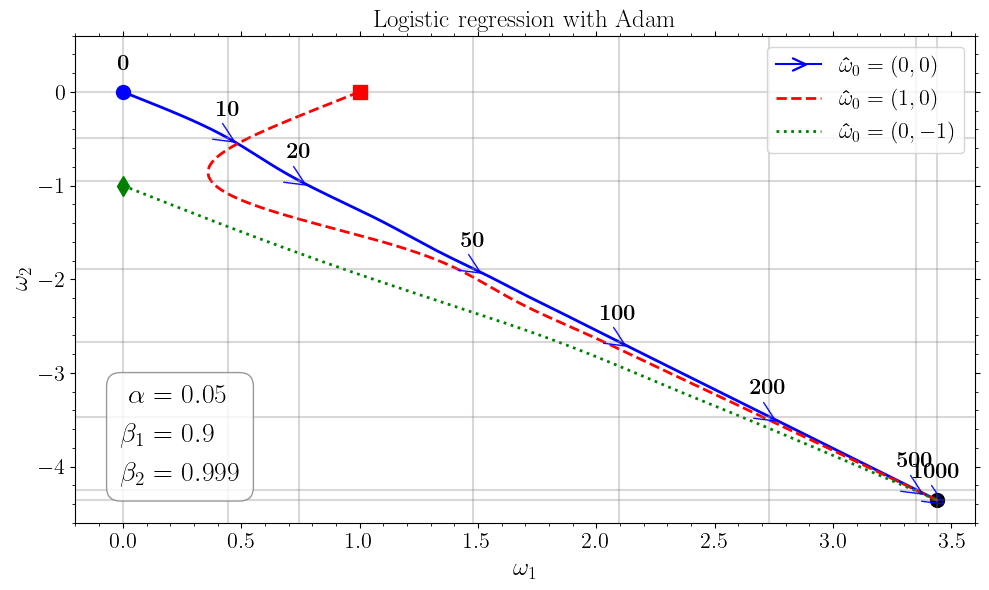

In [658]:
# --- Define data --- 
n_iter = len(omegas_Adam0005)
omegaEvolution0 = omegas_Adam0005
omegaEvolutionp1 = omegas_Adamp1005
omegaEvolutionm1 = omegas_Adamm1005

x_min, x_max = -0.2, 3.6
y_min, y_max = -4.6, 0.6

# --- Create custom tick arrays (you can adjust these as desired) ---
x_major_ticks = np.linspace(-0.5, 4, 10)
y_major_ticks = np.linspace(-5, 1, 7)

# For minor ticks, you can interpolate more finely:
x_minor_ticks = np.linspace(-0.5, 4, 46)
y_minor_ticks = np.linspace(-5, 1, 31)

# Enable LaTeX rendering for text
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['text.latex.preamble'] = r"""\usepackage{amsmath}
\usepackage{amsfonts}
\usepackage{amssymb}
\usepackage{bm}"""

# --- Create the figure and axis ---
fig, ax = plt.subplots(figsize=(10, 6))

# --- Plot the exact solution ---
line_exact, = ax.plot(exact_omega[0], exact_omega[1],
                        color='black', marker='o', markersize=10, label='Exact solution')

# --- Plot the first evolution with a solid line and markers ---
line_0, = ax.plot(omegaEvolution0[:, 0], omegaEvolution0[:, 1],
                  color='blue', 
                  linestyle="-",#(0, (5, 5)), 
                  linewidth=2,
                  #marker='o', markersize=7, 
                  label=r'$\mathbf{\hat\omega}_{0} = (0,0)$')

# --- Plot the second evolution with a dashed line and markers ---
line_p1, = ax.plot(omegaEvolutionp1[0, 0], omegaEvolutionp1[0, 1],
                   color='red', 
                   #alpha=0.6, 
                   linestyle="--", 
                   linewidth=2,
                    marker='s', markersize=7, label=r'$\mathbf{\hat\omega}_{0} = (1,0)$')

line_p1, = ax.plot(omegaEvolutionp1[:, 0], omegaEvolutionp1[:, 1],
                   color='red', 
                   #alpha=0.6, 
                   linestyle="--", 
                   linewidth=2,
                    marker=None, markersize=7, label=r'$\mathbf{\hat\omega}_{0} = (1,0)$')

# --- Plot the third evolution with a dashed line and markers ---
line_m1, = ax.plot(omegaEvolutionm1[0, 0], omegaEvolutionm1[0, 1],
                   color='green', 
                   #alpha=0.6, 
                   linestyle=":", 
                   linewidth=2,
                    marker='d', markersize=7, label=r'$\mathbf{\hat\omega}_{0} = (0,-1)$')

line_m1, = ax.plot(omegaEvolutionm1[:, 0], omegaEvolutionm1[:, 1],
                   color='green', 
                   #alpha=0.6, 
                   linestyle=":", 
                   linewidth=2,
                    marker=None, markersize=7, label=r'$\mathbf{\hat\omega}_{0} = (0,-1)$')

ax.set_xticks(x_major_ticks)
ax.set_xticks(x_minor_ticks, minor=True)
ax.set_yticks(y_major_ticks)
ax.set_yticks(y_minor_ticks, minor=True)
#ax.tick_params(axis='both', which='major', labelsize=16)
# Using tick_params:
ax.tick_params(axis='x', which='both', top=True, bottom=True, labelsize=16)
ax.tick_params(axis='y', which='both', left=True, right=True, labelsize=16)

# --- Customize axes ---
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_xlabel(r'$\omega_{1}$', fontsize=18)
ax.set_ylabel(r'$\omega_{2}$', fontsize=18)

# --- Annotate the first few iterations of omegaEvolution0 ---
#k = 0
for i in [0, 10, 20, 50, 100, 200, 500, 1000]:
    #k += 1
    x_val, y_val = omegaEvolution0[i, 0], omegaEvolution0[i, 1]
    # Place a text annotation below the point; adjust offset as needed.
    if i < 2000:
        ax.text(x_val, y_val + 0.4, r'$\mathbf{' + str(i) + '}$', fontsize=16, color='black',
                ha='center', va='top')
        if i >= 10:
            ax.text(x_val, y_val, r'$>$', fontsize=26, rotation=-32,
                    ha='center', va='center', color='blue')
    # Draw vertical lines at x_coords and horizontal lines at y_coords
    ax.vlines(omegaEvolution0[i,0], ymin=ax.get_ylim()[0], ymax=ax.get_ylim()[1],
              colors='gray', linestyles='-', alpha=0.3)
    ax.hlines(omegaEvolution0[i,1], xmin=ax.get_xlim()[0], xmax=ax.get_xlim()[1],
              colors='gray', linestyles='-', alpha=0.3)
    
plt.text(
    0.05, 0.28,
    r'$\begin{aligned} \alpha &= 0.05 \\ \beta_{1} &= 0.9 \\ \beta_{2} &= 0.999 \end{aligned}$',
    transform=plt.gca().transAxes,  # Use axis coordinates (0,0) lower left, (1,1) upper right
    horizontalalignment='left',     # Align text to the right edge of the box
    verticalalignment='top',         # Align text to the top edge of the box
    fontsize=20,
    color='black',
    bbox=dict(facecolor='white', edgecolor='gray', alpha=0.8, boxstyle='round,pad=0.5')
)

# Create a custom legend handle for the first evolution that shows the rotated ">" marker.
# Since there's no built-in rotated marker, we can simulate it using a Line2D object.
custom_handle = Line2D([], [], color='blue', linestyle="-",
                       marker=r'$>$', markersize=10, label=r'$\mathbf{\hat\omega}_{0} = (0,0)$')

# Combine the handles: for the first evolution, use our custom_handle;
# for the others, use the handles returned by ax.plot.
handles = [custom_handle, line_p1, line_m1]

# Create the legend with our custom handles.
ax.legend(handles=handles, loc='upper right', fontsize=16)

ax.plot(omegaEvolution0[0, 0], omegaEvolution0[0, 1],
        marker='o', markersize=10, color='blue')
ax.plot(omegaEvolutionp1[0, 0], omegaEvolutionp1[0, 1],
        marker='s', markersize=10, color='red')
ax.plot(omegaEvolutionm1[0, 0], omegaEvolutionm1[0, 1],
        marker='d', markersize=10, color='green')
#ax.plot(omegaEvolution0[-1, 0], omegaEvolution0[-1, 1],
#        marker='o', markersize=10, color='red')

plt.title(f'Logistic regression with Adam', fontsize = 18)

plt.tight_layout()

# --- Save the figure as a PDF (adjust the path as needed) ---
plt.savefig(f'/Users/rtorre/Dropbox/Apps/Overleaf/ML Methods for Physics/Figures/Chapter_3/logistic_Adam_alpha_005.pdf')
plt.show()

#### $\alpha = 0.1$

In [659]:
# Minimize the loss using the Newton method.
omegas_Adam001, losses_Adam001 = adam(X_train, p_train, np.array([0.0,0.0]), learning_rate = 0.1, max_iter = 10000)
omegas_Adamp101, losses_Adamp101 = adam(X_train, p_train, np.array([1.0,0.0]), learning_rate = 0.1, max_iter = 10000)
omegas_Adamm101, losses_Adamm101 = adam(X_train, p_train, np.array([0.0,-1.0]), learning_rate = 0.1, max_iter = 10000)

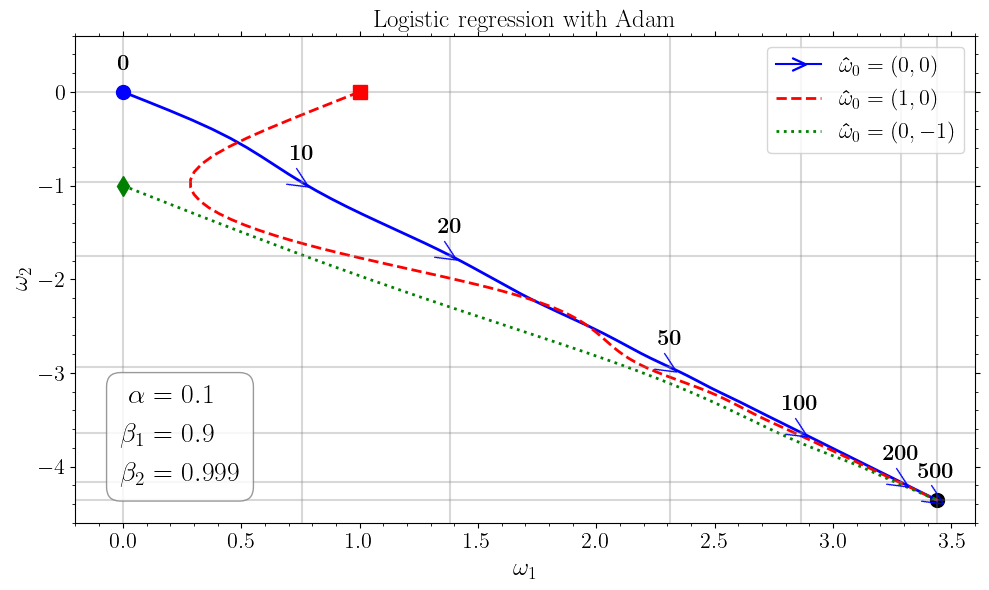

In [660]:
# --- Define data --- 
n_iter = len(omegas_Adam001)
omegaEvolution0 = omegas_Adam001
omegaEvolutionp1 = omegas_Adamp101
omegaEvolutionm1 = omegas_Adamm101

x_min, x_max = -0.2, 3.6
y_min, y_max = -4.6, 0.6

# --- Create custom tick arrays (you can adjust these as desired) ---
x_major_ticks = np.linspace(-0.5, 4, 10)
y_major_ticks = np.linspace(-5, 1, 7)

# For minor ticks, you can interpolate more finely:
x_minor_ticks = np.linspace(-0.5, 4, 46)
y_minor_ticks = np.linspace(-5, 1, 31)

# Enable LaTeX rendering for text
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['text.latex.preamble'] = r"""\usepackage{amsmath}
\usepackage{amsfonts}
\usepackage{amssymb}
\usepackage{bm}"""

# --- Create the figure and axis ---
fig, ax = plt.subplots(figsize=(10, 6))

# --- Plot the exact solution ---
line_exact, = ax.plot(exact_omega[0], exact_omega[1],
                        color='black', marker='o', markersize=10, label='Exact solution')

# --- Plot the first evolution with a solid line and markers ---
line_0, = ax.plot(omegaEvolution0[:, 0], omegaEvolution0[:, 1],
                  color='blue', 
                  linestyle="-",#(0, (5, 5)), 
                  linewidth=2,
                  #marker='o', markersize=7, 
                  label=r'$\mathbf{\hat\omega}_{0} = (0,0)$')

# --- Plot the second evolution with a dashed line and markers ---
line_p1, = ax.plot(omegaEvolutionp1[0, 0], omegaEvolutionp1[0, 1],
                   color='red', 
                   #alpha=0.6, 
                   linestyle="--", 
                   linewidth=2,
                    marker='s', markersize=7, label=r'$\mathbf{\hat\omega}_{0} = (1,0)$')

line_p1, = ax.plot(omegaEvolutionp1[:, 0], omegaEvolutionp1[:, 1],
                   color='red', 
                   #alpha=0.6, 
                   linestyle="--", 
                   linewidth=2,
                    marker=None, markersize=7, label=r'$\mathbf{\hat\omega}_{0} = (1,0)$')

# --- Plot the third evolution with a dashed line and markers ---
line_m1, = ax.plot(omegaEvolutionm1[0, 0], omegaEvolutionm1[0, 1],
                   color='green', 
                   #alpha=0.6, 
                   linestyle=":", 
                   linewidth=2,
                    marker='d', markersize=7, label=r'$\mathbf{\hat\omega}_{0} = (0,-1)$')

line_m1, = ax.plot(omegaEvolutionm1[:, 0], omegaEvolutionm1[:, 1],
                   color='green', 
                   #alpha=0.6, 
                   linestyle=":", 
                   linewidth=2,
                    marker=None, markersize=7, label=r'$\mathbf{\hat\omega}_{0} = (0,-1)$')

ax.set_xticks(x_major_ticks)
ax.set_xticks(x_minor_ticks, minor=True)
ax.set_yticks(y_major_ticks)
ax.set_yticks(y_minor_ticks, minor=True)
#ax.tick_params(axis='both', which='major', labelsize=16)
# Using tick_params:
ax.tick_params(axis='x', which='both', top=True, bottom=True, labelsize=16)
ax.tick_params(axis='y', which='both', left=True, right=True, labelsize=16)

# --- Customize axes ---
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_xlabel(r'$\omega_{1}$', fontsize=18)
ax.set_ylabel(r'$\omega_{2}$', fontsize=18)

# --- Annotate the first few iterations of omegaEvolution0 ---
#k = 0
for i in [0, 10, 20, 50, 100, 200, 500]:
    #k += 1
    x_val, y_val = omegaEvolution0[i, 0], omegaEvolution0[i, 1]
    # Place a text annotation below the point; adjust offset as needed.
    if i < 501:
        ax.text(x_val, y_val + 0.4, r'$\mathbf{' + str(i) + '}$', fontsize=16, color='black',
                ha='center', va='top')
        if i >= 10:
            ax.text(x_val, y_val, r'$>$', fontsize=26, rotation=-32,
                    ha='center', va='center', color='blue')
    # Draw vertical lines at x_coords and horizontal lines at y_coords
    ax.vlines(omegaEvolution0[i,0], ymin=ax.get_ylim()[0], ymax=ax.get_ylim()[1],
              colors='gray', linestyles='-', alpha=0.3)
    ax.hlines(omegaEvolution0[i,1], xmin=ax.get_xlim()[0], xmax=ax.get_xlim()[1],
              colors='gray', linestyles='-', alpha=0.3)
    
plt.text(
    0.05, 0.28,
    r'$\begin{aligned} \alpha &= 0.1 \\ \beta_{1} &= 0.9 \\ \beta_{2} &= 0.999 \end{aligned}$',
    transform=plt.gca().transAxes,  # Use axis coordinates (0,0) lower left, (1,1) upper right
    horizontalalignment='left',     # Align text to the right edge of the box
    verticalalignment='top',         # Align text to the top edge of the box
    fontsize=20,
    color='black',
    bbox=dict(facecolor='white', edgecolor='gray', alpha=0.8, boxstyle='round,pad=0.5')
)

# Create a custom legend handle for the first evolution that shows the rotated ">" marker.
# Since there's no built-in rotated marker, we can simulate it using a Line2D object.
custom_handle = Line2D([], [], color='blue', linestyle="-",
                       marker=r'$>$', markersize=10, label=r'$\mathbf{\hat\omega}_{0} = (0,0)$')

# Combine the handles: for the first evolution, use our custom_handle;
# for the others, use the handles returned by ax.plot.
handles = [custom_handle, line_p1, line_m1]

# Create the legend with our custom handles.
ax.legend(handles=handles, loc='upper right', fontsize=16)

ax.plot(omegaEvolution0[0, 0], omegaEvolution0[0, 1],
        marker='o', markersize=10, color='blue')
ax.plot(omegaEvolutionp1[0, 0], omegaEvolutionp1[0, 1],
        marker='s', markersize=10, color='red')
ax.plot(omegaEvolutionm1[0, 0], omegaEvolutionm1[0, 1],
        marker='d', markersize=10, color='green')
#ax.plot(omegaEvolution0[-1, 0], omegaEvolution0[-1, 1],
#        marker='o', markersize=10, color='red')

plt.title(f'Logistic regression with Adam', fontsize = 18)

plt.tight_layout()

# --- Save the figure as a PDF (adjust the path as needed) ---
plt.savefig(f'/Users/rtorre/Dropbox/Apps/Overleaf/ML Methods for Physics/Figures/Chapter_3/logistic_Adam_alpha_01.pdf')
plt.show()

#### $\alpha = 0.5$

In [680]:
# Minimize the loss using the Newton method.
omegas_Adam005, losses_Adam005 = adam(X_train, p_train, np.array([0.0,0.0]), learning_rate = 0.5, max_iter = 10000)
omegas_Adamp105, losses_Adamp105 = adam(X_train, p_train, np.array([1.0,0.0]), learning_rate = 0.5, max_iter = 10000)
omegas_Adamm105, losses_Adamm105 = adam(X_train, p_train, np.array([0.0,-1.0]), learning_rate = 0.5, max_iter = 10000)

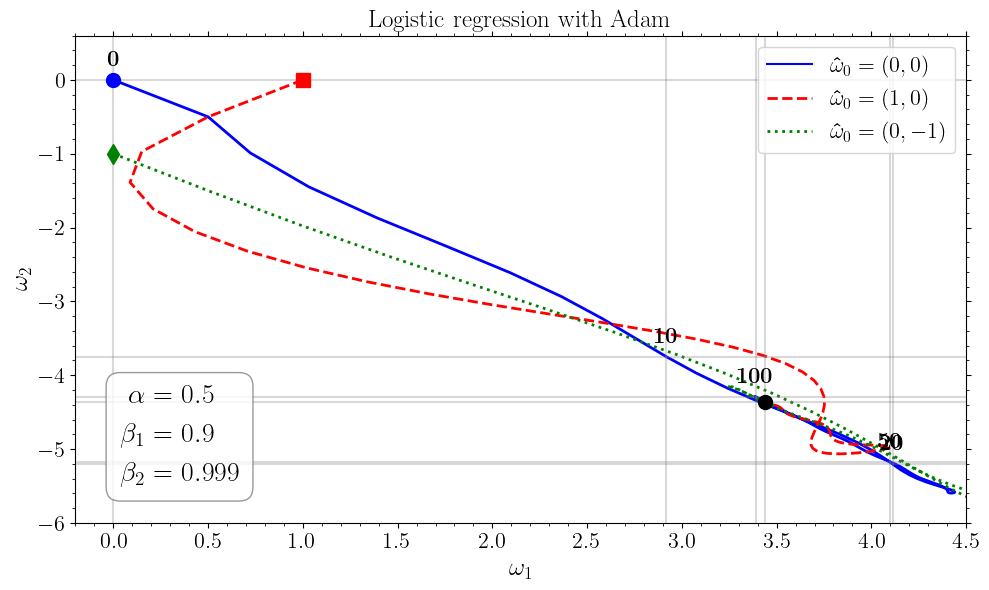

In [681]:
# --- Define data --- 
n_iter = len(omegas_Adam005)
omegaEvolution0 = omegas_Adam005
omegaEvolutionp1 = omegas_Adamp105
omegaEvolutionm1 = omegas_Adamm105

x_min, x_max = -0.2, 4.5
y_min, y_max = -6.0, 0.6

# --- Create custom tick arrays (you can adjust these as desired) ---
x_major_ticks = np.linspace(-0.5, 4.5, 11)
y_major_ticks = np.linspace(-6, 1, 8)

# For minor ticks, you can interpolate more finely:
x_minor_ticks = np.linspace(-0.5, 4.5, 51)
y_minor_ticks = np.linspace(-6, 1, 36)

# Enable LaTeX rendering for text
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['text.latex.preamble'] = r"""\usepackage{amsmath}
\usepackage{amsfonts}
\usepackage{amssymb}
\usepackage{bm}"""

# --- Create the figure and axis ---
fig, ax = plt.subplots(figsize=(10, 6))

# --- Plot the first evolution with a solid line and markers ---
line_0, = ax.plot(omegaEvolution0[:, 0], omegaEvolution0[:, 1],
                  color='blue', 
                  linestyle="-",#(0, (5, 5)), 
                  linewidth=2,
                  #marker='o', markersize=7, 
                  label=r'$\mathbf{\hat\omega}_{0} = (0,0)$')

# --- Plot the second evolution with a dashed line and markers ---
line_p1, = ax.plot(omegaEvolutionp1[0, 0], omegaEvolutionp1[0, 1],
                   color='red', 
                   #alpha=0.6, 
                   linestyle="--", 
                   linewidth=2,
                    marker='s', markersize=7, label=r'$\mathbf{\hat\omega}_{0} = (1,0)$')

line_p1, = ax.plot(omegaEvolutionp1[:, 0], omegaEvolutionp1[:, 1],
                   color='red', 
                   #alpha=0.6, 
                   linestyle="--", 
                   linewidth=2,
                    marker=None, markersize=7, label=r'$\mathbf{\hat\omega}_{0} = (1,0)$')

# --- Plot the third evolution with a dashed line and markers ---
line_m1, = ax.plot(omegaEvolutionm1[0, 0], omegaEvolutionm1[0, 1],
                   color='green', 
                   #alpha=0.6, 
                   linestyle=":", 
                   linewidth=2,
                    marker='d', markersize=7, label=r'$\mathbf{\hat\omega}_{0} = (0,-1)$')

line_m1, = ax.plot(omegaEvolutionm1[:, 0], omegaEvolutionm1[:, 1],
                   color='green', 
                   #alpha=0.6, 
                   linestyle=":", 
                   linewidth=2,
                    marker=None, markersize=7, label=r'$\mathbf{\hat\omega}_{0} = (0,-1)$')

ax.set_xticks(x_major_ticks)
ax.set_xticks(x_minor_ticks, minor=True)
ax.set_yticks(y_major_ticks)
ax.set_yticks(y_minor_ticks, minor=True)
#ax.tick_params(axis='both', which='major', labelsize=16)
# Using tick_params:
ax.tick_params(axis='x', which='both', top=True, bottom=True, labelsize=16)
ax.tick_params(axis='y', which='both', left=True, right=True, labelsize=16)

# --- Customize axes ---
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_xlabel(r'$\omega_{1}$', fontsize=18)
ax.set_ylabel(r'$\omega_{2}$', fontsize=18)

# --- Annotate the first few iterations of omegaEvolution0 ---
#k = 0
for i in [0, 10, 20, 50, 100, 190]:
    #k += 1
    x_val, y_val = omegaEvolution0[i, 0], omegaEvolution0[i, 1]
    # Place a text annotation below the point; adjust offset as needed.
    if i < 190:
        ax.text(x_val, y_val + 0.4, r'$\mathbf{' + str(i) + '}$', fontsize=16, color='black',
                ha='center', va='top')
        #if i >= 10:
        #    ax.text(x_val, y_val, r'$>$', fontsize=26, rotation=-32,
        #            ha='center', va='center', color='blue')
    # Draw vertical lines at x_coords and horizontal lines at y_coords
    ax.vlines(omegaEvolution0[i,0], ymin=ax.get_ylim()[0], ymax=ax.get_ylim()[1],
              colors='gray', linestyles='-', alpha=0.3)
    ax.hlines(omegaEvolution0[i,1], xmin=ax.get_xlim()[0], xmax=ax.get_xlim()[1],
              colors='gray', linestyles='-', alpha=0.3)
    
plt.text(
    0.05, 0.28,
    r'$\begin{aligned} \alpha &= 0.5 \\ \beta_{1} &= 0.9 \\ \beta_{2} &= 0.999 \end{aligned}$',
    transform=plt.gca().transAxes,  # Use axis coordinates (0,0) lower left, (1,1) upper right
    horizontalalignment='left',     # Align text to the right edge of the box
    verticalalignment='top',         # Align text to the top edge of the box
    fontsize=20,
    color='black',
    bbox=dict(facecolor='white', edgecolor='gray', alpha=0.8, boxstyle='round,pad=0.5')
)

# Create a custom legend handle for the first evolution that shows the rotated ">" marker.
# Since there's no built-in rotated marker, we can simulate it using a Line2D object.
custom_handle = Line2D([], [], color='blue', linestyle="-",
                       marker=None, markersize=10, label=r'$\mathbf{\hat\omega}_{0} = (0,0)$')

# Combine the handles: for the first evolution, use our custom_handle;
# for the others, use the handles returned by ax.plot.
handles = [custom_handle, line_p1, line_m1]

# Create the legend with our custom handles.
ax.legend(handles=handles, loc='upper right', fontsize=16)

ax.plot(omegaEvolution0[0, 0], omegaEvolution0[0, 1],
        marker='o', markersize=10, color='blue')
ax.plot(omegaEvolutionp1[0, 0], omegaEvolutionp1[0, 1],
        marker='s', markersize=10, color='red')
ax.plot(omegaEvolutionm1[0, 0], omegaEvolutionm1[0, 1],
        marker='d', markersize=10, color='green')
#ax.plot(omegaEvolution0[-1, 0], omegaEvolution0[-1, 1],
#        marker='o', markersize=10, color='red')

# --- Plot the exact solution ---
line_exact, = ax.plot(exact_omega[0], exact_omega[1],
                        color='black', marker='o', markersize=10, label='Exact solution')

plt.title(f'Logistic regression with Adam', fontsize = 18)

plt.tight_layout()

# --- Save the figure as a PDF (adjust the path as needed) ---
plt.savefig(f'/Users/rtorre/Dropbox/Apps/Overleaf/ML Methods for Physics/Figures/Chapter_3/logistic_Adam_alpha_05.pdf')
plt.show()

#### $\alpha = 1$

In [672]:
# Minimize the loss using the Newton method.
omegas_Adam01, losses_Adam01 = adam(X_train, p_train, np.array([0.0,0.0]), learning_rate = 1.0, max_iter = 10000)
omegas_Adamp11, losses_Adamp11 = adam(X_train, p_train, np.array([1.0,0.0]), learning_rate = 1.0, max_iter = 10000)
omegas_Adamm11, losses_Adamm11 = adam(X_train, p_train, np.array([0.0,-1.0]), learning_rate = 1.0, max_iter = 10000)

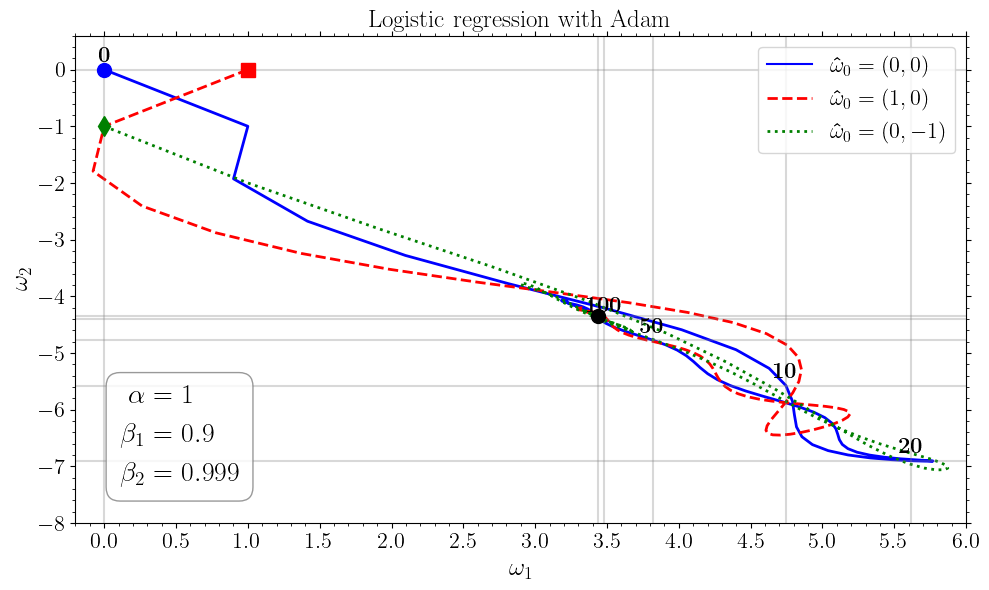

In [723]:
# --- Define data --- 
n_iter = len(omegas_Adam01)
omegaEvolution0 = omegas_Adam01
omegaEvolutionp1 = omegas_Adamp11
omegaEvolutionm1 = omegas_Adamm11

x_min, x_max = -0.2, 6.0
y_min, y_max = -8.0, 0.6

# --- Create custom tick arrays (you can adjust these as desired) ---
x_major_ticks = np.linspace(-0.5, 6, 14)
y_major_ticks = np.linspace(-8, 1, 10)

# For minor ticks, you can interpolate more finely:
x_minor_ticks = np.linspace(-0.5, 6, 66)
y_minor_ticks = np.linspace(-8, 1, 46)

# Enable LaTeX rendering for text
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['text.latex.preamble'] = r"""\usepackage{amsmath}
\usepackage{amsfonts}
\usepackage{amssymb}
\usepackage{bm}"""

# --- Create the figure and axis ---
fig, ax = plt.subplots(figsize=(10, 6))

# --- Plot the first evolution with a solid line and markers ---
line_0, = ax.plot(omegaEvolution0[:, 0], omegaEvolution0[:, 1],
                  color='blue', 
                  linestyle="-",#(0, (5, 5)), 
                  linewidth=2,
                  #marker='o', markersize=7, 
                  label=r'$\mathbf{\hat\omega}_{0} = (0,0)$')

# --- Plot the second evolution with a dashed line and markers ---
line_p1, = ax.plot(omegaEvolutionp1[0, 0], omegaEvolutionp1[0, 1],
                   color='red', 
                   #alpha=0.6, 
                   linestyle="--", 
                   linewidth=2,
                    marker='s', markersize=7, label=r'$\mathbf{\hat\omega}_{0} = (1,0)$')

line_p1, = ax.plot(omegaEvolutionp1[:, 0], omegaEvolutionp1[:, 1],
                   color='red', 
                   #alpha=0.6, 
                   linestyle="--", 
                   linewidth=2,
                    marker=None, markersize=7, label=r'$\mathbf{\hat\omega}_{0} = (1,0)$')

# --- Plot the third evolution with a dashed line and markers ---
line_m1, = ax.plot(omegaEvolutionm1[0, 0], omegaEvolutionm1[0, 1],
                   color='green', 
                   #alpha=0.6, 
                   linestyle=":", 
                   linewidth=2,
                    marker='d', markersize=7, label=r'$\mathbf{\hat\omega}_{0} = (0,-1)$')

line_m1, = ax.plot(omegaEvolutionm1[:, 0], omegaEvolutionm1[:, 1],
                   color='green', 
                   #alpha=0.6, 
                   linestyle=":", 
                   linewidth=2,
                    marker=None, markersize=7, label=r'$\mathbf{\hat\omega}_{0} = (0,-1)$')

ax.set_xticks(x_major_ticks)
ax.set_xticks(x_minor_ticks, minor=True)
ax.set_yticks(y_major_ticks)
ax.set_yticks(y_minor_ticks, minor=True)
#ax.tick_params(axis='both', which='major', labelsize=16)
# Using tick_params:
ax.tick_params(axis='x', which='both', top=True, bottom=True, labelsize=16)
ax.tick_params(axis='y', which='both', left=True, right=True, labelsize=16)

# --- Customize axes ---
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_xlabel(r'$\omega_{1}$', fontsize=18)
ax.set_ylabel(r'$\omega_{2}$', fontsize=18)

# --- Annotate the first few iterations of omegaEvolution0 ---
#k = 0
for i in [0, 10, 20, 50, 100, 198]:
    #k += 1
    x_val, y_val = omegaEvolution0[i, 0], omegaEvolution0[i, 1]
    # Place a text annotation below the point; adjust offset as needed.
    if i < 198:
        ax.text(x_val, y_val + 0.4, r'$\mathbf{' + str(i) + '}$', fontsize=16, color='black',
                ha='center', va='top')
    # Draw vertical lines at x_coords and horizontal lines at y_coords
    ax.vlines(omegaEvolution0[i,0], ymin=ax.get_ylim()[0], ymax=ax.get_ylim()[1],
              colors='gray', linestyles='-', alpha=0.3)
    ax.hlines(omegaEvolution0[i,1], xmin=ax.get_xlim()[0], xmax=ax.get_xlim()[1],
              colors='gray', linestyles='-', alpha=0.3)
    
plt.text(
    0.05, 0.28,
    r'$\begin{aligned} \alpha &= 1 \\ \beta_{1} &= 0.9 \\ \beta_{2} &= 0.999 \end{aligned}$',
    transform=plt.gca().transAxes,  # Use axis coordinates (0,0) lower left, (1,1) upper right
    horizontalalignment='left',     # Align text to the right edge of the box
    verticalalignment='top',         # Align text to the top edge of the box
    fontsize=20,
    color='black',
    bbox=dict(facecolor='white', edgecolor='gray', alpha=0.8, boxstyle='round,pad=0.5')
)

# Create a custom legend handle for the first evolution that shows the rotated ">" marker.
# Since there's no built-in rotated marker, we can simulate it using a Line2D object.
custom_handle = Line2D([], [], color='blue', linestyle="-",
                       marker=None, markersize=10, label=r'$\mathbf{\hat\omega}_{0} = (0,0)$')

# Combine the handles: for the first evolution, use our custom_handle;
# for the others, use the handles returned by ax.plot.
handles = [custom_handle, line_p1, line_m1]

# Create the legend with our custom handles.
ax.legend(handles=handles, loc='upper right', fontsize=16)

ax.plot(omegaEvolution0[0, 0], omegaEvolution0[0, 1],
        marker='o', markersize=10, color='blue')
ax.plot(omegaEvolutionp1[0, 0], omegaEvolutionp1[0, 1],
        marker='s', markersize=10, color='red')
ax.plot(omegaEvolutionm1[0, 0], omegaEvolutionm1[0, 1],
        marker='d', markersize=10, color='green')
#ax.plot(omegaEvolution0[-1, 0], omegaEvolution0[-1, 1],
#        marker='o', markersize=10, color='red')

# --- Plot the exact solution ---
line_exact, = ax.plot(exact_omega[0], exact_omega[1],
                        color='black', marker='o', markersize=10, label='Exact solution')

plt.title(f'Logistic regression with Adam', fontsize = 18)

plt.tight_layout()

# --- Save the figure as a PDF (adjust the path as needed) ---
plt.savefig(f'/Users/rtorre/Dropbox/Apps/Overleaf/ML Methods for Physics/Figures/Chapter_3/logistic_Adam_alpha_1.pdf')
plt.show()

#### Convergence

In [714]:
res03 = []
for lr in [0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1., 2.]:
    omegas_Adam0, losses_Adam0 = adam(X_train, p_train, np.array([0.0,0.0]), learning_rate = lr, max_iter = 100000, tol = 1e-10)
    tmp = [[lr, i, np.sqrt(np.sum((omegas_Adam0[i]-exact_omega)**2)),np.sqrt(np.sum((omegas_Adam0[i]-exact_omega)**2))<1e-03] for i in range(len(omegas_Adam0)) if np.sqrt(np.sum((omegas_Adam0[i]-exact_omega)**2))<1e-03][0]
    res03.append([tmp[0], tmp[1]])
    print(f'For alpha = {lr}, the algorithm converges to the exact solution after {tmp[1]} iterations, with a distance of {tmp[2]}')
res03 = np.array(res03)

For alpha = 0.01, the algorithm converges to the exact solution after 3731 iterations, with a distance of 0.0009989693123131937
For alpha = 0.02, the algorithm converges to the exact solution after 2241 iterations, with a distance of 0.000995809006299706
For alpha = 0.05, the algorithm converges to the exact solution after 986 iterations, with a distance of 0.0009996110724021917
For alpha = 0.1, the algorithm converges to the exact solution after 480 iterations, with a distance of 0.0009822238768184828
For alpha = 0.2, the algorithm converges to the exact solution after 178 iterations, with a distance of 0.0009506976365935925
For alpha = 0.5, the algorithm converges to the exact solution after 121 iterations, with a distance of 0.0003534198630395497
For alpha = 1.0, the algorithm converges to the exact solution after 133 iterations, with a distance of 0.000528587984239517
For alpha = 2.0, the algorithm converges to the exact solution after 149 iterations, with a distance of 0.000579075

In [715]:
res05 = []
for lr in [0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1., 2.]:
    omegas_Adam0, losses_Adam0 = adam(X_train, p_train, np.array([0.0,0.0]), learning_rate = lr, max_iter = 100000, tol = 1e-10)
    tmp = [[lr, i, np.sqrt(np.sum((omegas_Adam0[i]-exact_omega)**2)),np.sqrt(np.sum((omegas_Adam0[i]-exact_omega)**2))<1e-05] for i in range(len(omegas_Adam0)) if np.sqrt(np.sum((omegas_Adam0[i]-exact_omega)**2))<1e-05][0]
    res05.append([tmp[0], tmp[1]])
    print(f'For alpha = {lr}, the algorithm converges to the exact solution after {tmp[1]} iterations, with a distance of {tmp[2]}')
res05 = np.array(res05)

For alpha = 0.01, the algorithm converges to the exact solution after 4503 iterations, with a distance of 9.928969567185226e-06
For alpha = 0.02, the algorithm converges to the exact solution after 2828 iterations, with a distance of 9.979860303126215e-06
For alpha = 0.05, the algorithm converges to the exact solution after 1298 iterations, with a distance of 9.931196551072912e-06
For alpha = 0.1, the algorithm converges to the exact solution after 635 iterations, with a distance of 9.930641198941192e-06
For alpha = 0.2, the algorithm converges to the exact solution after 222 iterations, with a distance of 7.183251442623384e-06
For alpha = 0.5, the algorithm converges to the exact solution after 192 iterations, with a distance of 1.7954591633597328e-06
For alpha = 1.0, the algorithm converges to the exact solution after 219 iterations, with a distance of 8.009945475907709e-06
For alpha = 2.0, the algorithm converges to the exact solution after 235 iterations, with a distance of 5.57171

In [716]:
res07 = []
for lr in [0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1., 2.]:
    omegas_Adam0, losses_Adam0 = adam(X_train, p_train, np.array([0.0,0.0]), learning_rate = lr, max_iter = 100000, tol = 1e-10)
    tmp = [[lr, i, np.sqrt(np.sum((omegas_Adam0[i]-exact_omega)**2)),np.sqrt(np.sum((omegas_Adam0[i]-exact_omega)**2))<1e-07] for i in range(len(omegas_Adam0)) if np.sqrt(np.sum((omegas_Adam0[i]-exact_omega)**2))<1e-07][0]
    res07.append([tmp[0], tmp[1]])
    print(f'For alpha = {lr}, the algorithm converges to the exact solution after {tmp[1]} iterations, with a distance of {tmp[2]}')
res07 = np.array(res07)

For alpha = 0.01, the algorithm converges to the exact solution after 5044 iterations, with a distance of 9.907435698820164e-08
For alpha = 0.02, the algorithm converges to the exact solution after 3264 iterations, with a distance of 9.916693601735904e-08
For alpha = 0.05, the algorithm converges to the exact solution after 1544 iterations, with a distance of 9.888252862610105e-08
For alpha = 0.1, the algorithm converges to the exact solution after 754 iterations, with a distance of 9.848105459452133e-08
For alpha = 0.2, the algorithm converges to the exact solution after 308 iterations, with a distance of 9.30882877163987e-08
For alpha = 0.5, the algorithm converges to the exact solution after 284 iterations, with a distance of 7.96033976760642e-08
For alpha = 1.0, the algorithm converges to the exact solution after 296 iterations, with a distance of 5.6822135261849685e-08
For alpha = 2.0, the algorithm converges to the exact solution after 326 iterations, with a distance of 7.2155212

In [717]:
res10 = []
for lr in [0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1., 2.]:
    omegas_Adam0, losses_Adam0 = adam(X_train, p_train, np.array([0.0,0.0]), learning_rate = lr, max_iter = 100000, tol = 1e-15)
    tmp = [[lr, i, np.sqrt(np.sum((omegas_Adam0[i]-exact_omega)**2)),np.sqrt(np.sum((omegas_Adam0[i]-exact_omega)**2))<1e-10] for i in range(len(omegas_Adam0)) if np.sqrt(np.sum((omegas_Adam0[i]-exact_omega)**2))<1e-10][0]
    res10.append([tmp[0], tmp[1]])
    print(f'For alpha = {lr}, the algorithm converges to the exact solution after {tmp[1]} iterations, with a distance of {tmp[2]}')
res10 = np.array(res10)

For alpha = 0.01, the algorithm converges to the exact solution after 5633 iterations, with a distance of 9.980525371468026e-11
For alpha = 0.02, the algorithm converges to the exact solution after 3758 iterations, with a distance of 9.916594980763185e-11
For alpha = 0.05, the algorithm converges to the exact solution after 1837 iterations, with a distance of 9.988585083873378e-11
For alpha = 0.1, the algorithm converges to the exact solution after 877 iterations, with a distance of 9.822363775035156e-11
For alpha = 0.2, the algorithm converges to the exact solution after 443 iterations, with a distance of 5.8141802136495514e-11
For alpha = 0.5, the algorithm converges to the exact solution after 442 iterations, with a distance of 8.44380150127242e-11
For alpha = 1.0, the algorithm converges to the exact solution after 449 iterations, with a distance of 9.828299953063768e-11
For alpha = 2.0, the algorithm converges to the exact solution after 443 iterations, with a distance of 7.819344

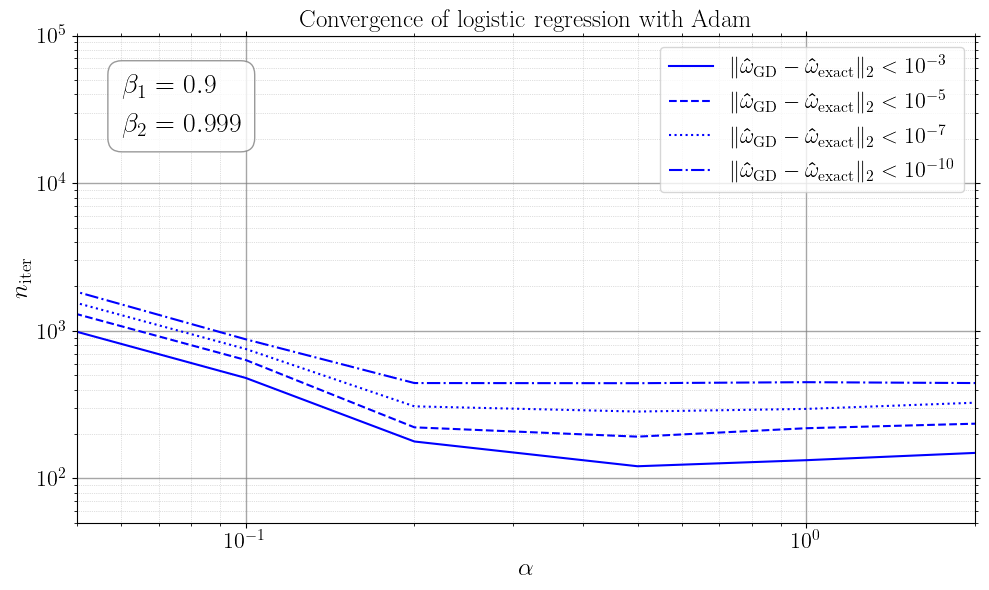

In [722]:
# Enable LaTeX rendering for text
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['text.latex.preamble'] = r"""\usepackage{amsmath}
\usepackage{amsfonts}
\usepackage{amssymb}
\usepackage{bm}"""

# --- Create the figure and axis ---
fig, ax = plt.subplots(figsize=(10, 6))

# Set log scales
ax.set_xscale('log')
ax.set_yscale('log')

# Set plot range
ax.set_xlim(0.05, 2)
ax.set_ylim(50, 100000)

# --- Plot the exact solution ---
ax.loglog(res03[:,0], res03[:,1],
    color='blue', linestyle = "-", markersize=10, label=r'$\| \mathbf{\hat\omega}_{\text{GD}} - \mathbf{\hat\omega}_{\text{exact}} \|_{2} < 10^{-3}$')
ax.loglog(res05[:,0], res05[:,1],
    color='blue', linestyle = "--", label=r'$\| \mathbf{\hat\omega}_{\text{GD}} - \mathbf{\hat\omega}_{\text{exact}} \|_{2} < 10^{-5}$')
ax.loglog(res07[:,0], res07[:,1],
    color='blue', linestyle = ":", label=r'$\| \mathbf{\hat\omega}_{\text{GD}} - \mathbf{\hat\omega}_{\text{exact}} \|_{2} < 10^{-7}$')
ax.loglog(res10[:,0], res10[:,1],
    color='blue', linestyle = "-.", label=r'$\| \mathbf{\hat\omega}_{\text{GD}} - \mathbf{\hat\omega}_{\text{exact}} \|_{2} < 10^{-10}$')

# --- Customize axes ---
ax.set_xlabel(r'$\alpha$', fontsize=18)
ax.set_ylabel(r'$n_{\text{iter}}$', fontsize=18)

# Create the legend with our custom handles.
ax.legend(loc='upper right', fontsize=16)

# Using tick_params:
ax.tick_params(axis='x', which='both', top=True, bottom=True, labelsize=16)
ax.tick_params(axis='y', which='both', left=True, right=True, labelsize=16)

# Draw vertical lines at x_coords and horizontal lines at y_coords
ax.grid(which='minor', linestyle=':', linewidth=0.5, color='gray', alpha=0.5)
ax.grid(which='major', linestyle='-', linewidth=1, color='gray', alpha=0.7)

plt.title(f'Convergence of logistic regression with Adam', fontsize = 18)

plt.text(
    0.05, 0.92,
    r'$\begin{aligned} \beta_{1} &= 0.9 \\ \beta_{2} &= 0.999 \end{aligned}$',
    transform=plt.gca().transAxes,  # Use axis coordinates (0,0) lower left, (1,1) upper right
    horizontalalignment='left',     # Align text to the right edge of the box
    verticalalignment='top',         # Align text to the top edge of the box
    fontsize=20,
    color='black',
    bbox=dict(facecolor='white', edgecolor='gray', alpha=0.8, boxstyle='round,pad=0.5')
)

plt.tight_layout()

# --- Save the figure as a PDF (adjust the path as needed) ---
plt.savefig(f'/Users/rtorre/Dropbox/Apps/Overleaf/ML Methods for Physics/Figures/Chapter_3/logistic_Adam_convergence.pdf')

plt.show()